# Pima Indians Diabetes Database
"This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage."

-------------------

Comenzamos cargando los datos proporcionados en un archivo CSV llamado diabetes csv.

In [ ]:
import pandas as pd
data = pd.read_csv('diabetes.csv')
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


-------------------

En esta parte del proyecto, realizamos un análisis inicial del dataset para entender mejor su estructura y evaluar la calidad de los datos. Esto incluye verificar los tipos de datos, las dimensiones, la presencia de valores nulos y algunas estadísticas descriptivas.

### Exploración del dataset:

* Utilizamos data.info() para obtener información general sobre el DataFrame, incluyendo el número de filas y columnas, los tipos de datos en cada columna y el consumo de memoria.
Esto confirmó que el dataset tiene 768 registros y 9 columnas, con valores no nulos en todas las columnas.

### Análisis estadístico básico:

* Con data.describe(), pudimos revisar estadísticas básicas como la media, mediana y percentiles de las variables. Esto nos dio un panorama general de la distribución de los valores en el dataset.
Revisión de valores nulos:

* Usamos data.isnull().sum() para verificar si hay valores faltantes en las columnas. El resultado muestra que no hay valores nulos en ninguna columna.

In [ ]:
print(data.info())
print("\n")
print(data.describe)
print("\n")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66           

### Resultados Obtenidos:
Aunque no hay valores nulos, se identificaron valores sospechosos al observar el dataset, como ceros en columnas donde no deberían existir valores nulos o irreales, como Glucose, BloodPressure, SkinThickness, Insulin, y BMI. Estos valores serán tratados como un posible problema de datos en pasos posteriores.

### Problemáticas Detectadas:
Aunque no hay valores nulos explícitos, los ceros en ciertas columnas probablemente sean valores faltantes codificados de forma incorrecta, lo que plantea preguntas como:

* ¿Qué tan frecuentes son estos valores en cada columna?
* ¿Se deben imputar o eliminar? Estas cuestiones serán abordadas en las siguientes etapas del preprocesamiento.

------------------------------------

En este paso, identificamos la cantidad de valores que son iguales a 0 en columnas donde no tendría sentido que existieran tales valores. Esto incluye variables como niveles de glucosa, presión arterial, espesor de piel, niveles de insulina y el índice de masa corporal (BMI). Estas columnas están relacionadas con características biológicas, y un valor de 0 en estas variables es poco realista o clínicamente improbable.

### Selección de columnas relevantes:

Se seleccionaron las columnas donde un valor igual a 0 no tiene sentido lógico en este contexto: Glucose, BloodPressure, SkinThickness, Insulin, y BMI.
Conteo de valores iguales a cero:

Usamos (data[cols_to_check] == 0).sum() para contar cuántos ceros aparecen en cada una de estas columnas.

In [ ]:
# Columnas donde el valor 0 no tiene sentido
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Contar valores 0 en cada columna
zero_counts = (data[cols_to_check] == 0).sum()

# Imprimir los resultados
print("Cantidad de valores 0 en columnas donde no deberían existir:")
print(zero_counts)

Cantidad de valores 0 en columnas donde no deberían existir:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### Resultados Obtenidos:
El conteo reveló una cantidad significativa de ceros en algunas columnas:

* Glucose: 5 valores de 0 (0.65% del dataset).
* BloodPressure: 35 valores de 0 (4.56% del dataset).
* SkinThickness: 227 valores de 0 (29.56% del dataset).
* Insulin: 374 valores de 0 (48.70% del dataset).
* BMI: 11 valores de 0 (1.43% del dataset).

Esto confirma que los ceros están presentes en una proporción considerable en ciertas columnas, especialmente en SkinThickness e Insulin.

### Problemáticas Detectadas:
Los valores de 0 en estas columnas probablemente sean un indicador de datos faltantes que no fueron correctamente codificados. El tratamiento de estos valores es crucial, ya que su gran proporción podría afectar la calidad del modelo.

------------------

En este paso del proyecto, exploramos visualmente las relaciones entre las características del dataset y el resultado (Outcome), así como la correlación entre las variables. Utilizamos gráficos como boxplots, histogramas, y un heatmap de correlaciones para identificar patrones, tendencias, y posibles problemáticas en los datos.

<ipython-input-6-6214b78de9a9>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data, palette='Set2')
<ipython-input-6-6214b78de9a9>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data, palette='Set2')
<ipython-input-6-6214b78de9a9>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data, palette='Set2')
<ipython-input-6-6214b78de9a9>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

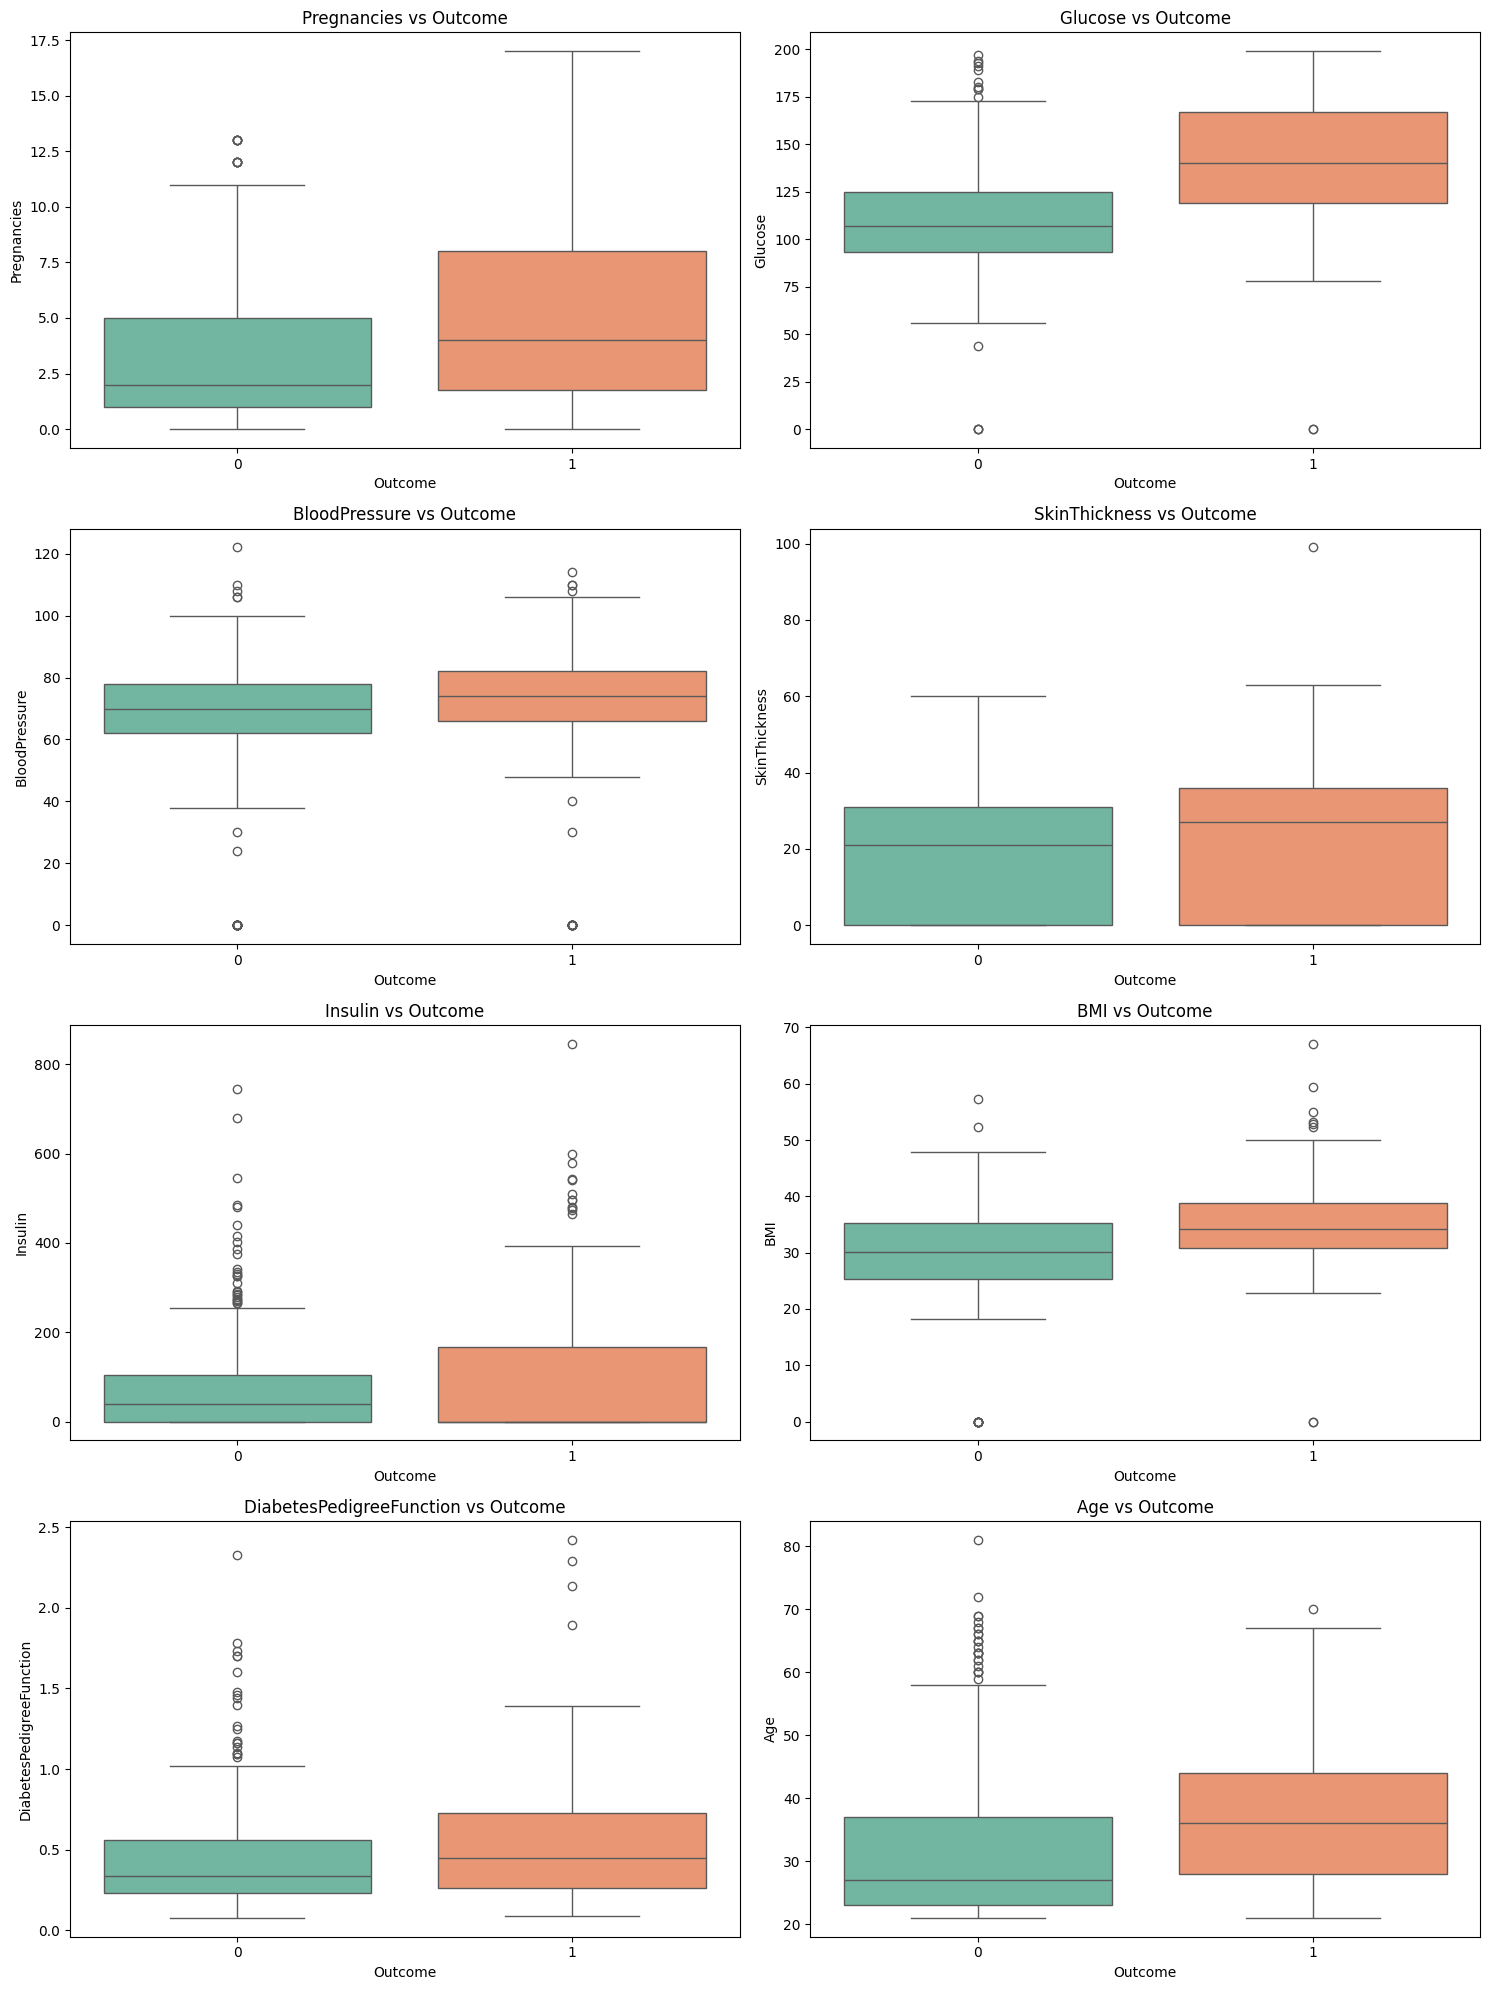

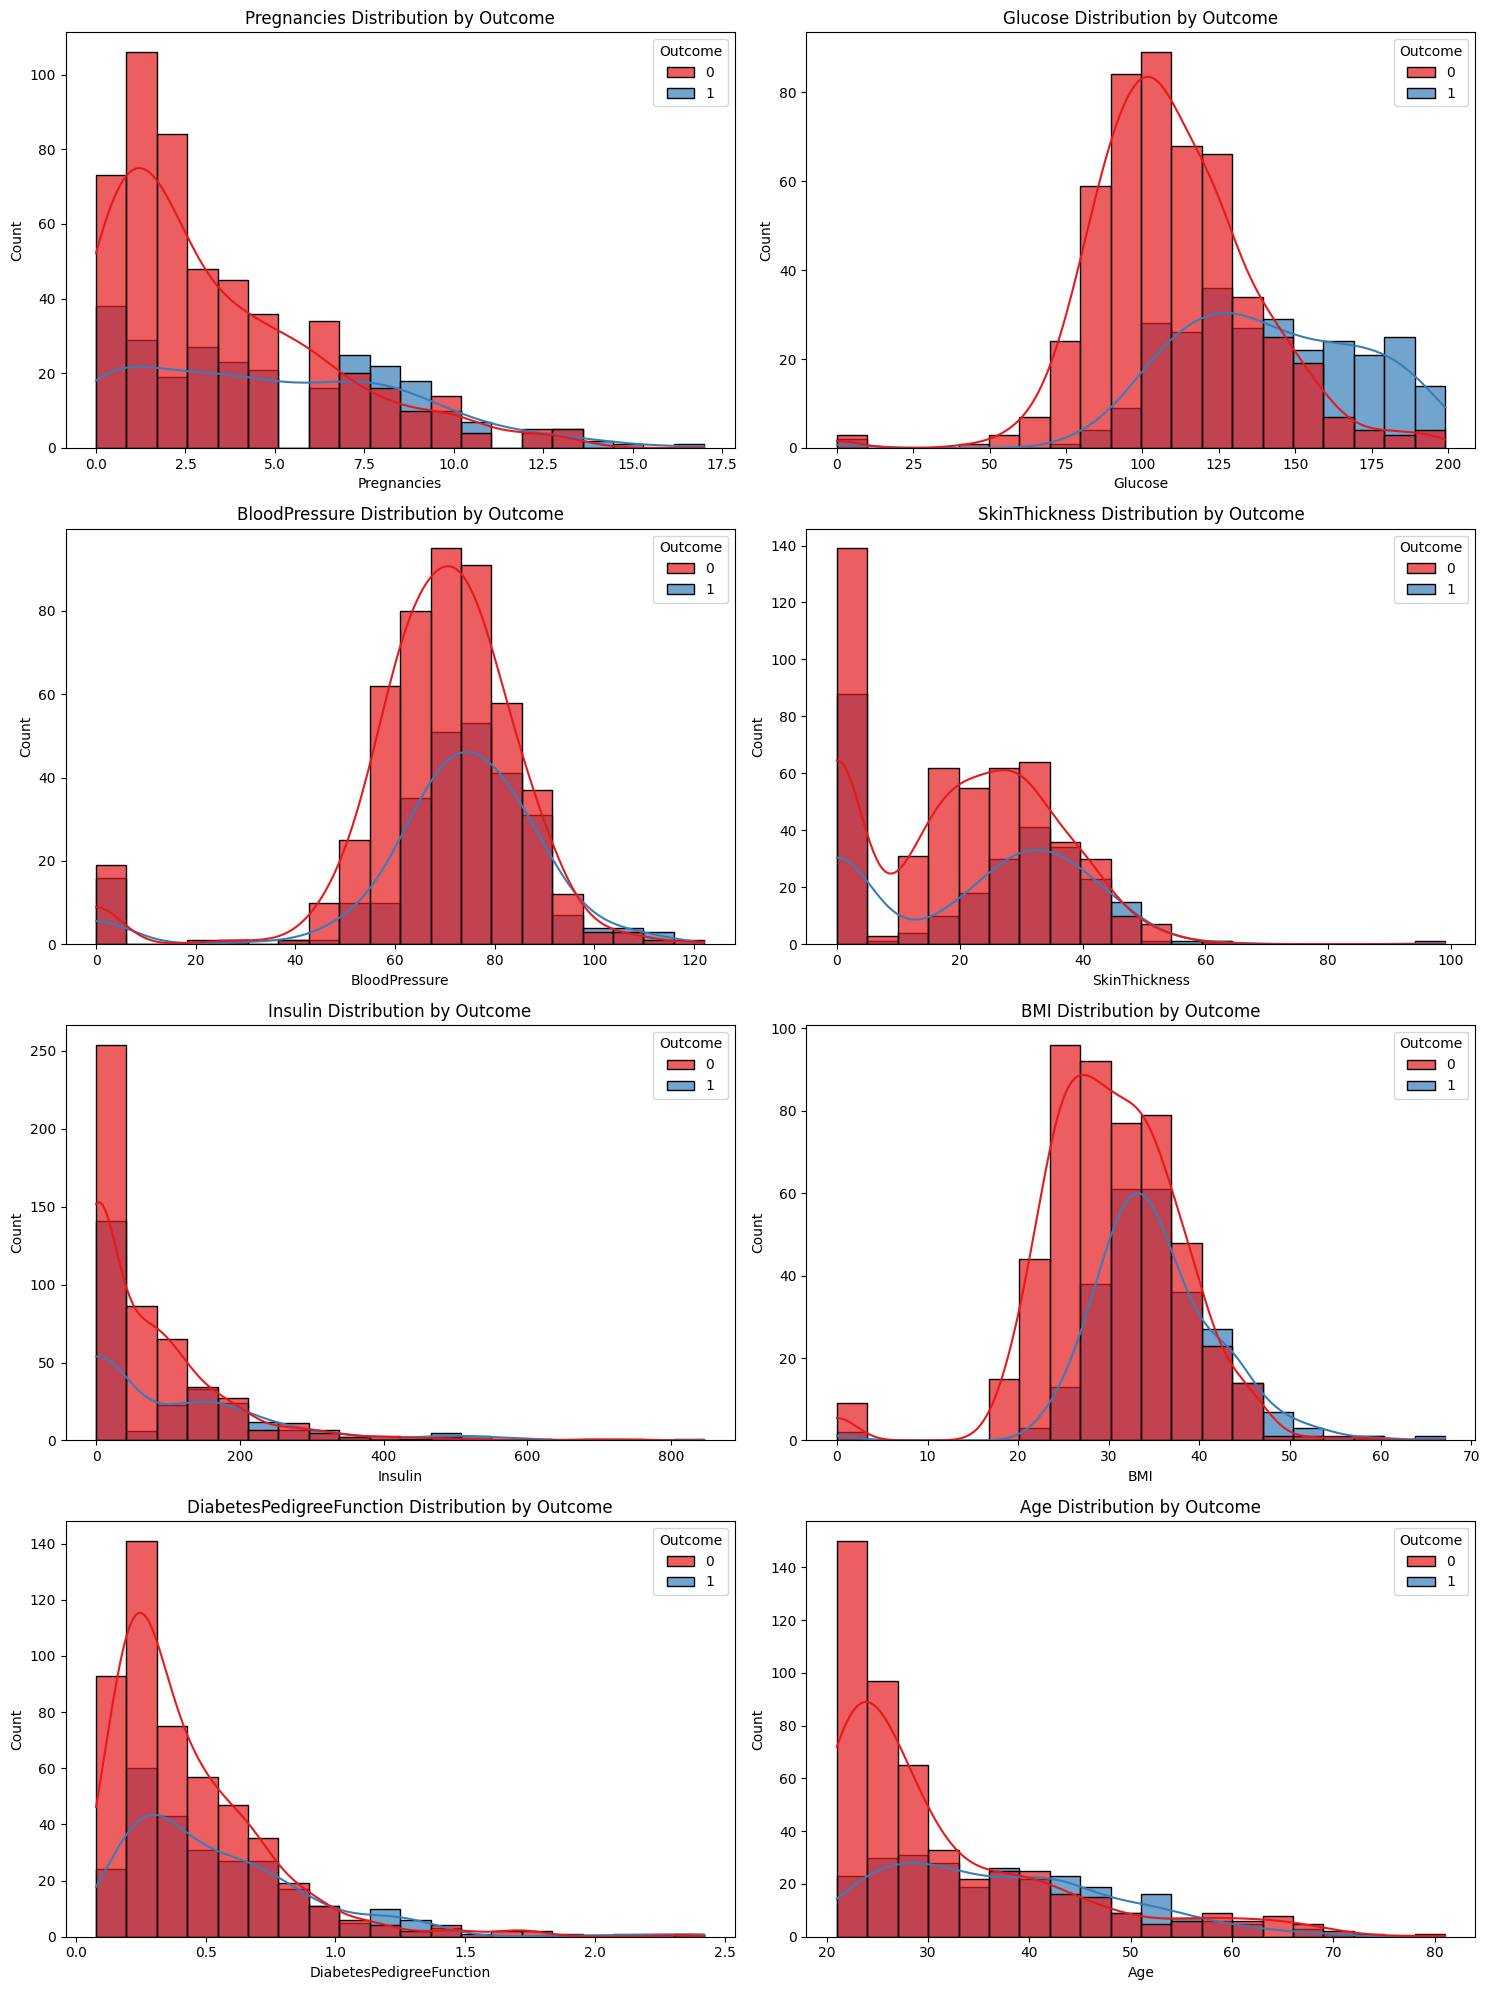

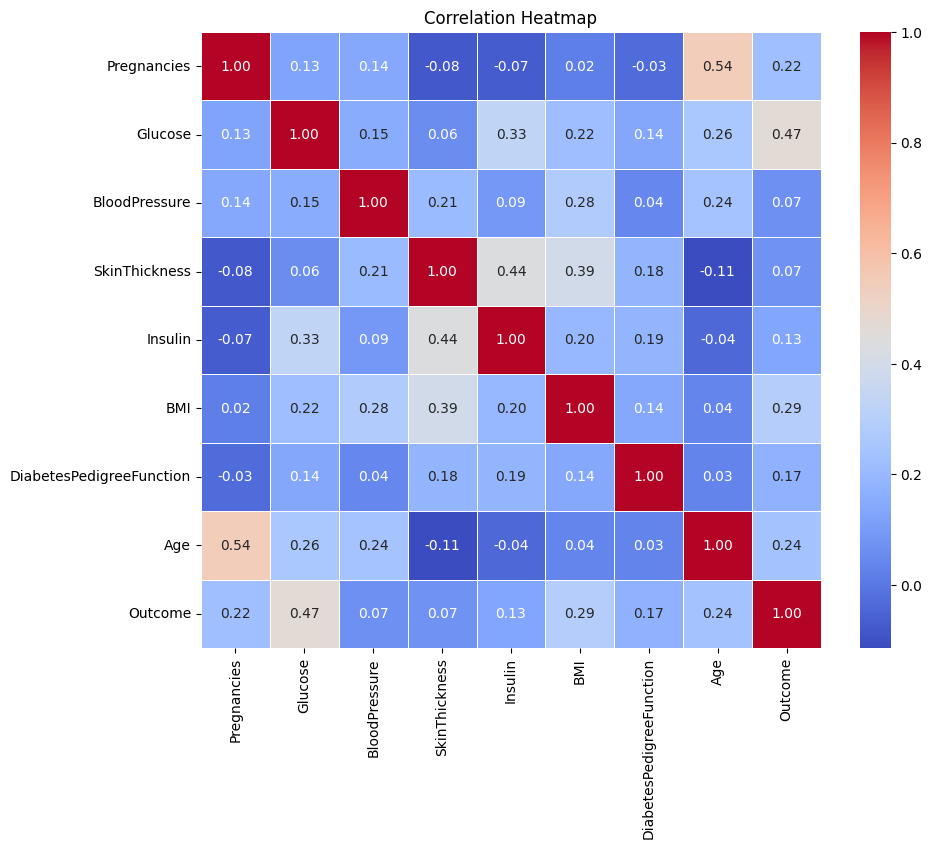

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración inicial de los gráficos
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plt.figure(figsize=(15, 20))

for i, col in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x='Outcome', y=col, data=data, palette='Set2')
    plt.title(f'{col} vs Outcome')
    plt.tight_layout()

plt.show()


plt.figure(figsize=(15, 20))

for i, col in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(data, x=col, hue='Outcome', kde=True, palette='Set1', bins=20, alpha=0.7)
    plt.title(f'{col} Distribution by Outcome')
    plt.tight_layout()

plt.show()


# Calcular correlación
correlation = data.corr()

# Crear un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


### Gráficos Realizados y su Propósito:

#### Boxplots por Outcome:

Propósito: Comparar la distribución de cada característica entre las clases Outcome = 0 (no diabetes) y Outcome = 1 (diabetes).

##### Resultados observados:
* Glucose y BMI muestran diferencias marcadas entre los grupos, sugiriendo que estas características son importantes para predecir el Outcome.
* BloodPressure muestra diferencias leves, aunque no tan claras como las anteriores.
* Tanto Insulin como SkinThickness tienen valores atípicos significativos, especialmente en Outcome = 1, lo que plantea preguntas sobre la imputación de sus valores faltantes.

#### Histogramas por Outcome:

Propósito: Observar la distribución de cada característica por clase para entender si hay patrones significativos.
##### Resultados observados:
* Glucose, BloodPressure, y BMI tienen distribuciones relativamente normales (aunque sesgadas) que diferencian entre los outcomes.
Insulin tiene una distribución altamente sesgada, con un gran número de valores en cero.
* SkinThickness también presenta una alta proporción de valores en cero y una distribución menos diferenciada entre los outcomes.

#### Mapa de calor de correlaciones (Heatmap):

Propósito: Visualizar las correlaciones lineales entre las características y con el Outcome.
##### Resultados observados:
* Glucose tiene la correlación más alta con Outcome (~0.47), seguida por BMI (~0.29) y Age (~0.24).
* Pregnancies muestra una correlación notable con Age (~0.54), lo que tiene sentido dado que el número de embarazos tiende a aumentar con la edad.
* SkinThickness e Insulin tienen correlaciones bajas con Outcome (0.07 y 0.13, respectivamente), lo que podría justificar su eliminación o imputación dependiendo del análisis posterior.

### Problemáticas Detectadas:

##### Valores Cero en Insulin y SkinThickness:
* Estas columnas tienen una gran cantidad de ceros, lo que podría dificultar la construcción de un modelo si no se maneja adecuadamente.
* Además, su baja correlación con Outcome sugiere que podrían no aportar mucho valor predictivo.

##### Posible Sesgo en las Distribuciones:
* Glucose y BMI presentan distribuciones sesgadas, lo que podría requerir normalización o estandarización en pasos posteriores para mejorar el rendimiento del modelo.

##### Relaciones No Lineales:

Aunque los gráficos revelan patrones, algunas relaciones parecen más complejas y pueden no ser completamente capturadas por modelos lineales.

--------------

En este paso, exploramos cómo cada característica del dataset se relaciona con la probabilidad de que el Outcome sea igual a 1 (diabetes). Utilizamos gráficos de dispersión para visualizar el porcentaje de casos con Outcome = 1 para cada valor único de las características seleccionadas.

### Agrupación de los datos:
* Para cada característica (Pregnancies, Glucose, BloodPressure, etc.), calculamos el porcentaje de registros donde el Outcome es igual a 1, agrupando los valores únicos de la característica.

### Visualización con gráficos de dispersión:
* Graficamos el porcentaje calculado en función de los valores únicos de cada característica. Esto permite identificar patrones o tendencias entre cada variable y la probabilidad de que una persona tenga diabetes.

<ipython-input-7-f28b6dffe17d>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-7-f28b6dffe17d>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-7-f28b6dffe17d>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-7-f28b6dffe17d>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-7-f28b6dffe17d>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, p

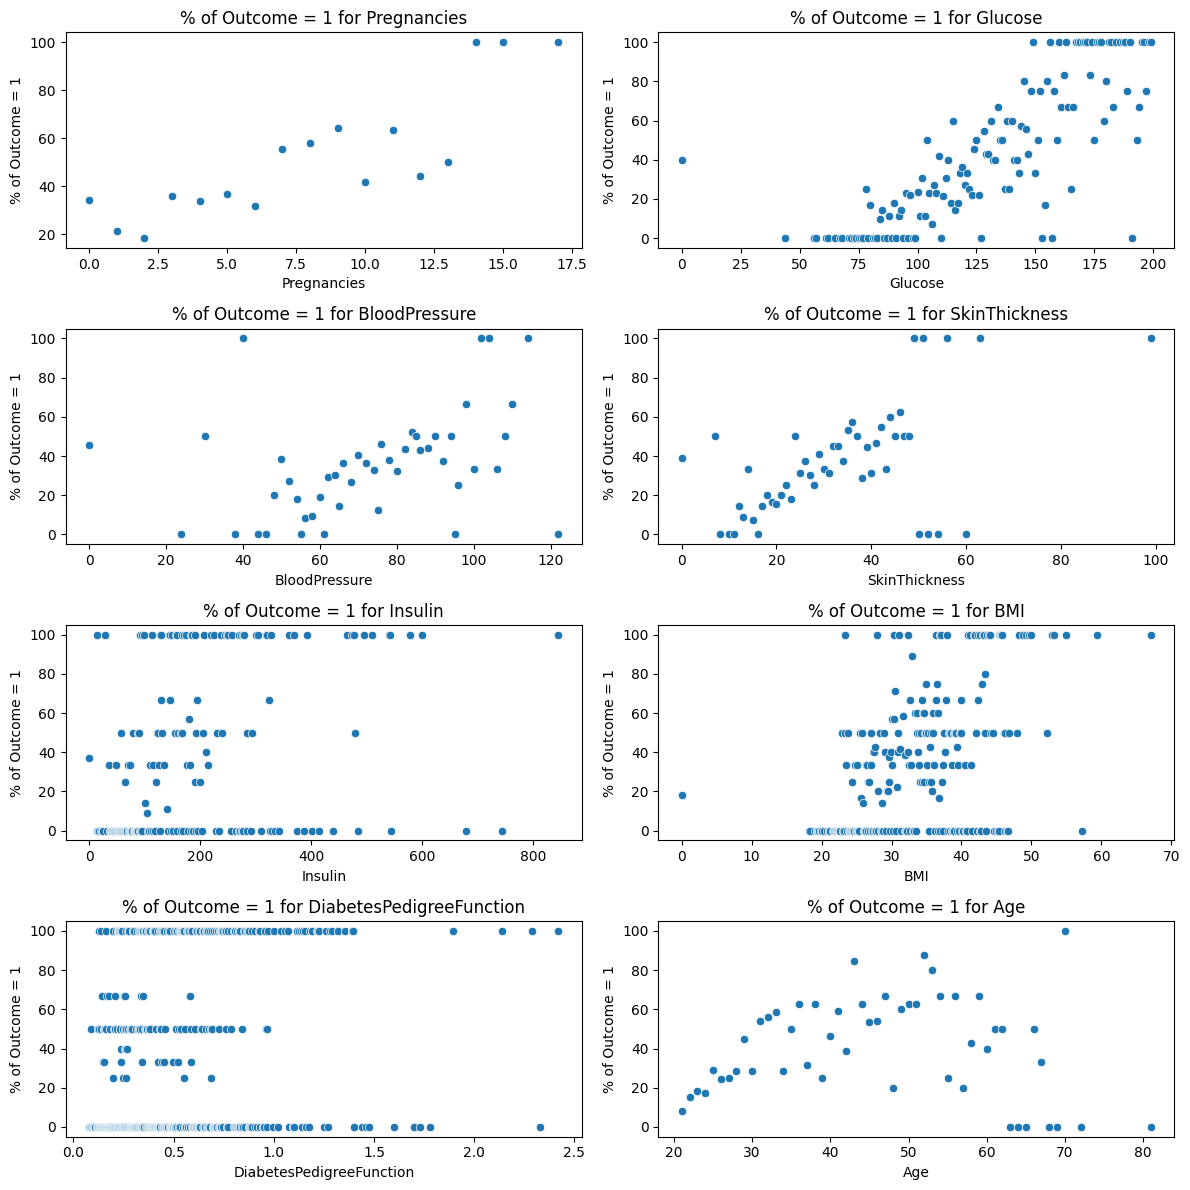

In [ ]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Crear una figura con subgráficos para cada feature
plt.figure(figsize=(12, 12))

# Graficar cada feature con respecto al % de Outcome = 1
for i, feature in enumerate(features, 1):
    plt.subplot(4, 2, i)  # Crear una rejilla de 4x2 subgráficos

    # Calcular el % de outcomes 1 para cada valor único del feature
    outcome_percentage = data.groupby(feature)['Outcome'].mean() * 100  # Porcentaje

    # Graficar el resultado
    sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
    plt.title(f'% of Outcome = 1 for {feature}')
    plt.xlabel(feature)
    plt.ylabel('% of Outcome = 1')
    plt.tight_layout()

plt.show()

### Resultados Observados:

##### Glucose:
* Muestra una relación progresiva clara: a medida que aumenta el nivel de glucosa, el porcentaje de Outcome = 1 también aumenta, lo que confirma su importancia en la predicción.

##### BloodPressure:
* Presenta una relación más estable, con porcentajes de Outcome = 1 alrededor del 40%-50% para valores en un rango normal. Esto sugiere que la presión arterial tiene un impacto más moderado en la predicción.

##### Insulin y SkinThickness:
* Estas variables tienen patrones más complejos, influenciados por la gran cantidad de valores en cero. Aunque pueden aportar algo de información, su relación con el Outcome no parece ser tan clara como en otras características.

##### BMI:
* Muestra un aumento claro en el porcentaje de Outcome = 1 conforme los valores de BMI aumentan, especialmente en valores superiores a 30, lo cual coincide con lo esperado clínicamente.

##### Pregnancies y Age:
* Estas variables muestran patrones interesantes pero más heterogéneos. Por ejemplo, la cantidad de embarazos tiende a aumentar el porcentaje de Outcome = 1, especialmente en valores más altos (>5).

##### DiabetesPedigreeFunction:
* Tiene una relación positiva: conforme el valor del coeficiente de parentesco aumenta, también lo hace el porcentaje de Outcome = 1.

### Problemáticas Detectadas:

##### Distribución Desbalanceada en Insulin y SkinThickness:
* Los valores en cero desbalancean el análisis, lo que sugiere la necesidad de imputar o manejar estos valores para obtener una mejor representación de las relaciones.

##### Ruido en las Características con Valores Pequeños:
* Algunas características, como Pregnancies y BloodPressure, tienen valores únicos con pocos registros, lo que puede generar ruido estadístico y afectar la estabilidad de los porcentajes calculados.

-------------

En esta sección, visualizamos los features suponiendo una eliminación de valores en 0 para los features problemáticos, en comparación con una versión de los mismos que combina imputación con eliminación, según el caso.

<ipython-input-8-3e0fcbd43417>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_imputed[col].replace(0, data[col].median(), inplace=True)
<ipython-input-8-3e0fcbd43417>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

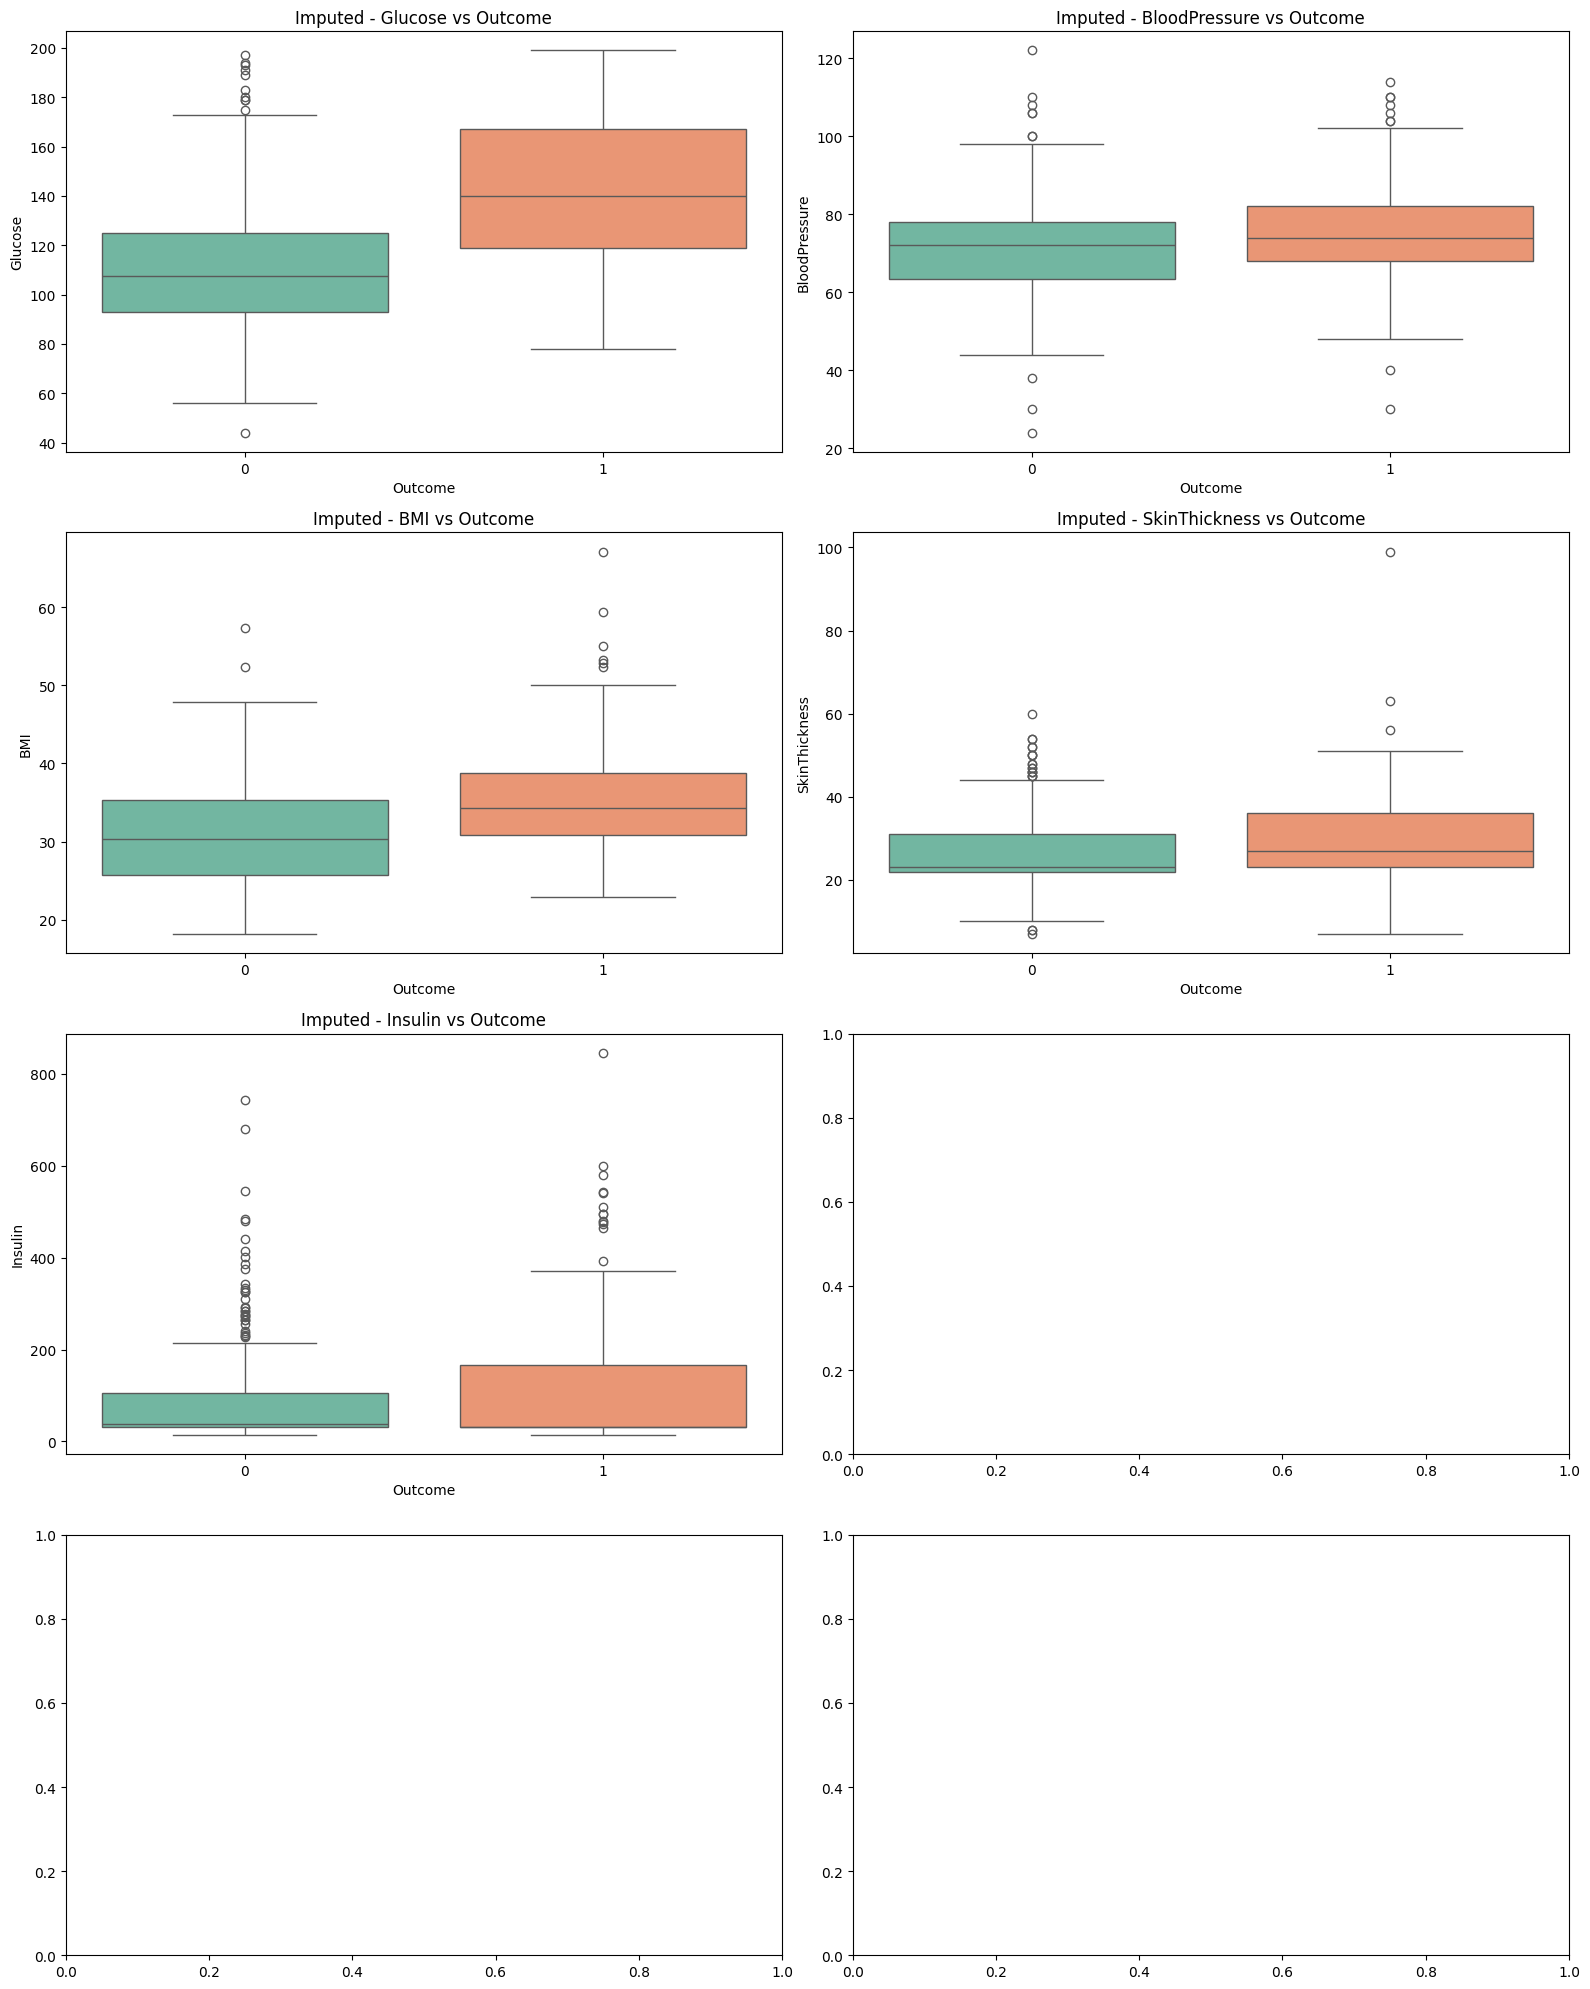

<ipython-input-8-3e0fcbd43417>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data_deleted_then_imputed, ax=axes[i], palette='Set1')
<ipython-input-8-3e0fcbd43417>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data_deleted_then_imputed, ax=axes[i], palette='Set1')
<ipython-input-8-3e0fcbd43417>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data_deleted_then_imputed, ax=axes[i], palette='Set1')
<ipython-input-8-3e0fcbd43417>:36: FutureWarning: 

Passing `pal

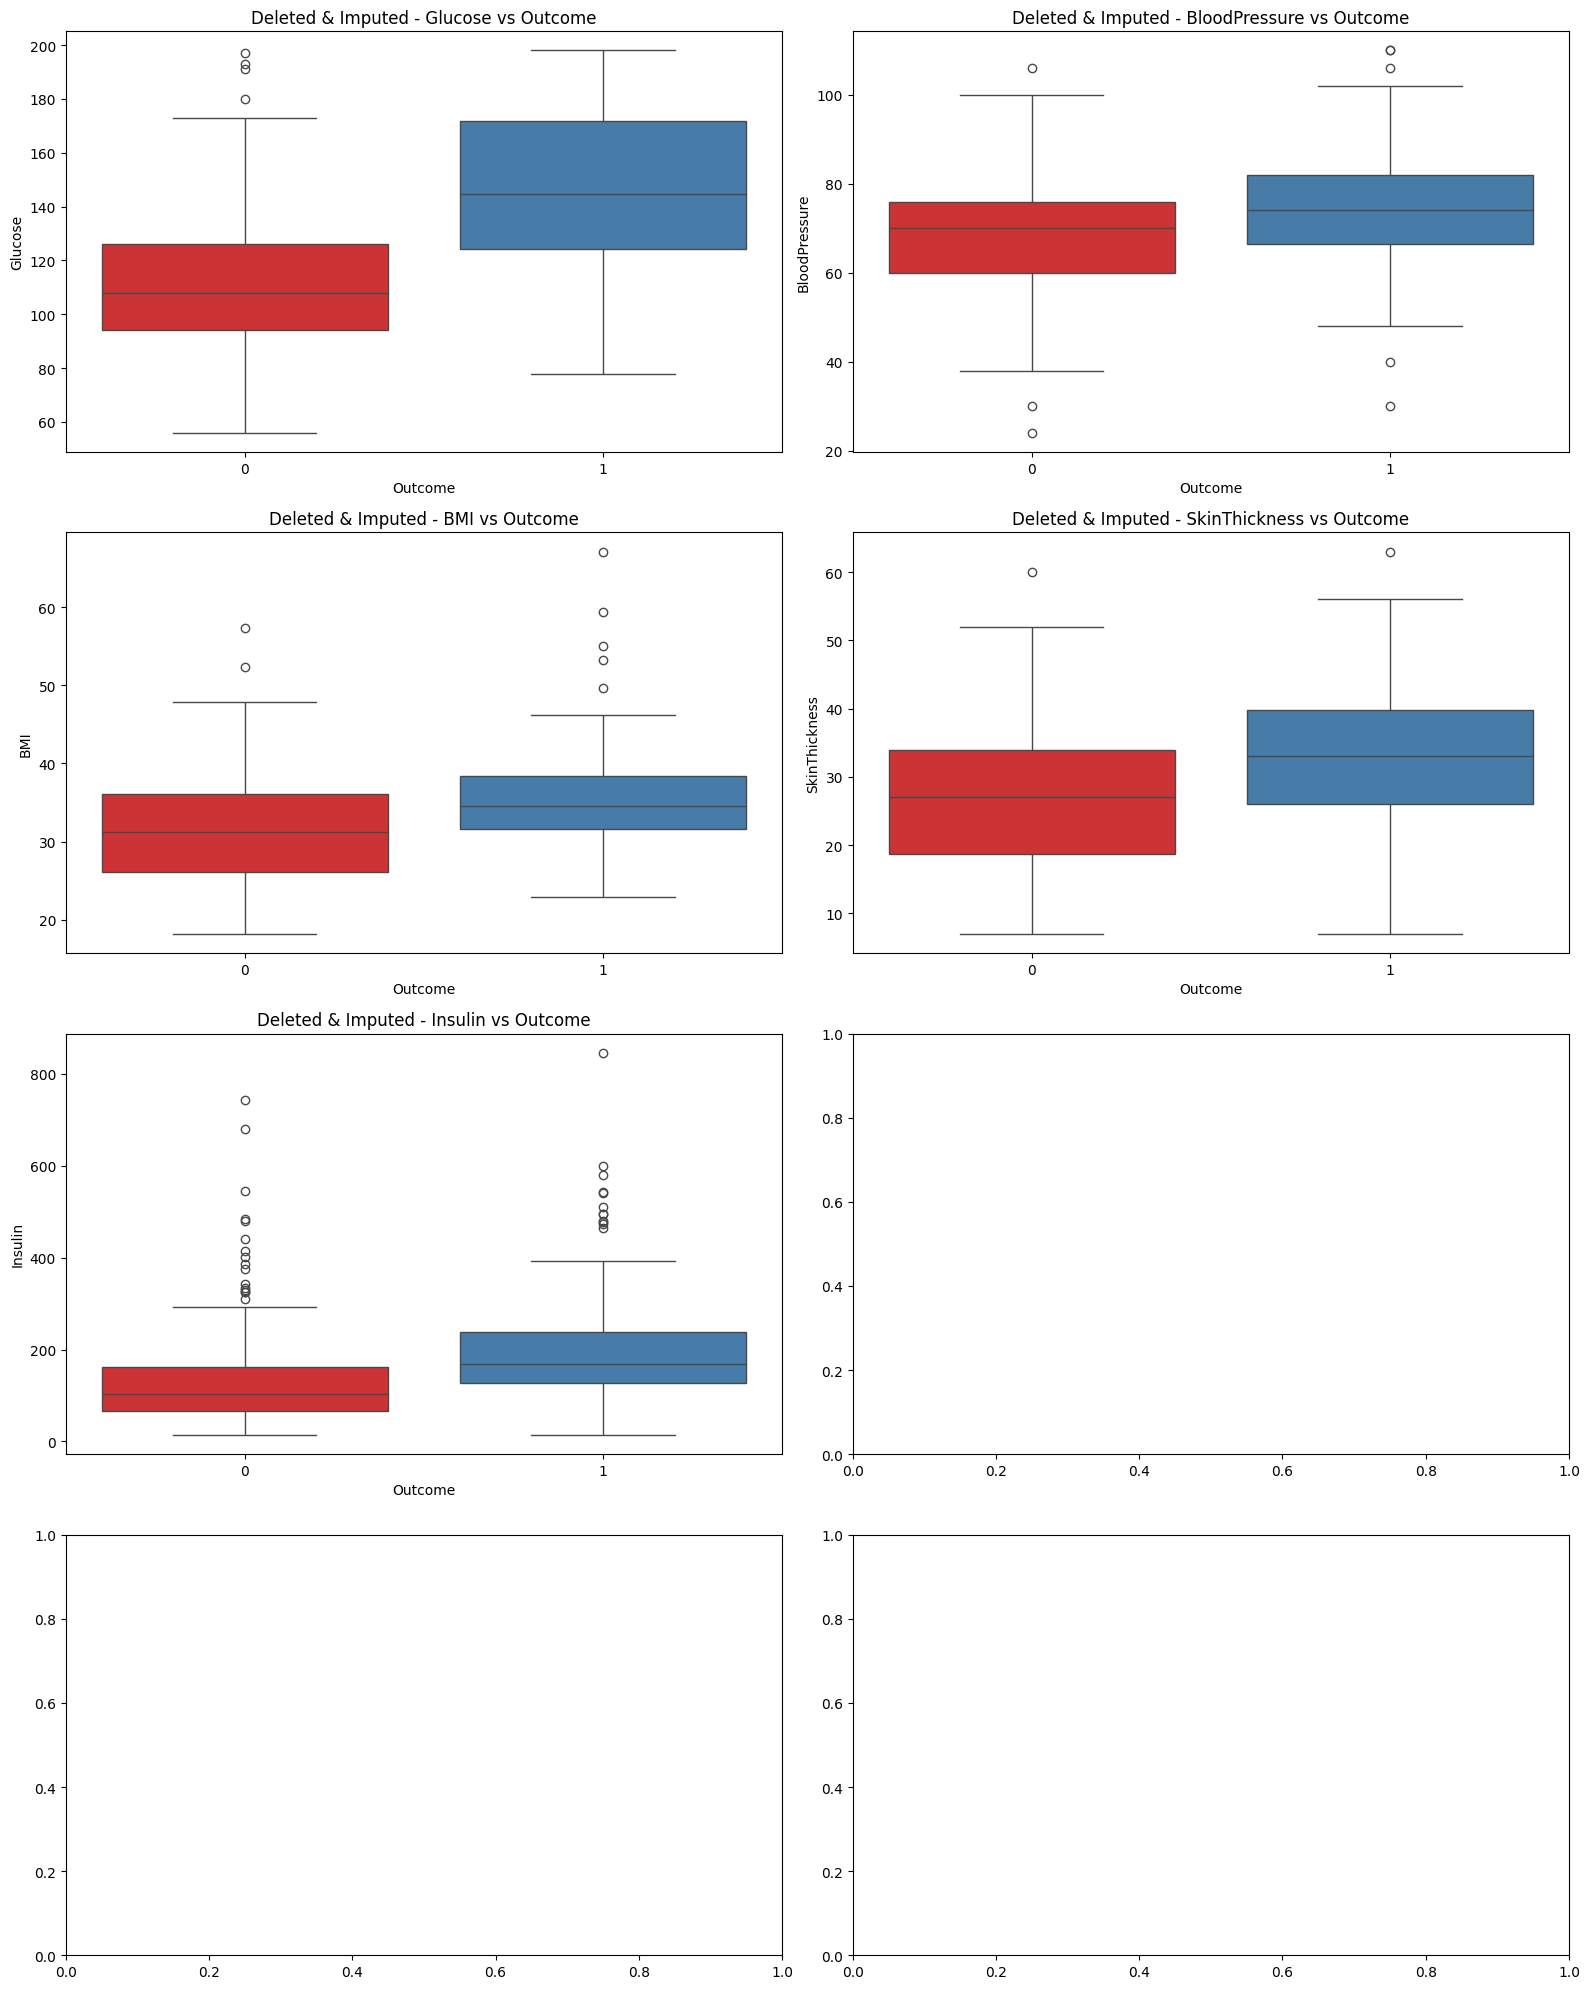

In [ ]:
import numpy as np

# Listas de columnas a procesar
columns_to_impute = ['Glucose', 'BloodPressure', 'BMI']
columns_to_delete_then_impute = ['SkinThickness', 'Insulin']

# Copia del dataset original para la versión imputada
data_imputed = data.copy()
for col in columns_to_impute + columns_to_delete_then_impute:
    data_imputed[col].replace(0, data[col].median(), inplace=True)

# Crear una copia para la versión eliminada e imputada
data_deleted_then_imputed = data.copy()
data_deleted_then_imputed = data_deleted_then_imputed[(data_deleted_then_imputed['SkinThickness'] != 0) &
                                                      (data_deleted_then_imputed['Insulin'] != 0)]
for col in columns_to_impute:
    data_deleted_then_imputed[col].replace(0, data[col].median(), inplace=True)

# Graficar correlaciones con Outcome para ambas versiones
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
columns_to_plot = columns_to_impute + columns_to_delete_then_impute

# Versión imputada
for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='Outcome', y=col, data=data_imputed, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Imputed - {col} vs Outcome')
plt.tight_layout()
plt.show()

# Graficar para la versión eliminada e imputada
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='Outcome', y=col, data=data_deleted_then_imputed, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Deleted & Imputed - {col} vs Outcome')
plt.tight_layout()
plt.show()


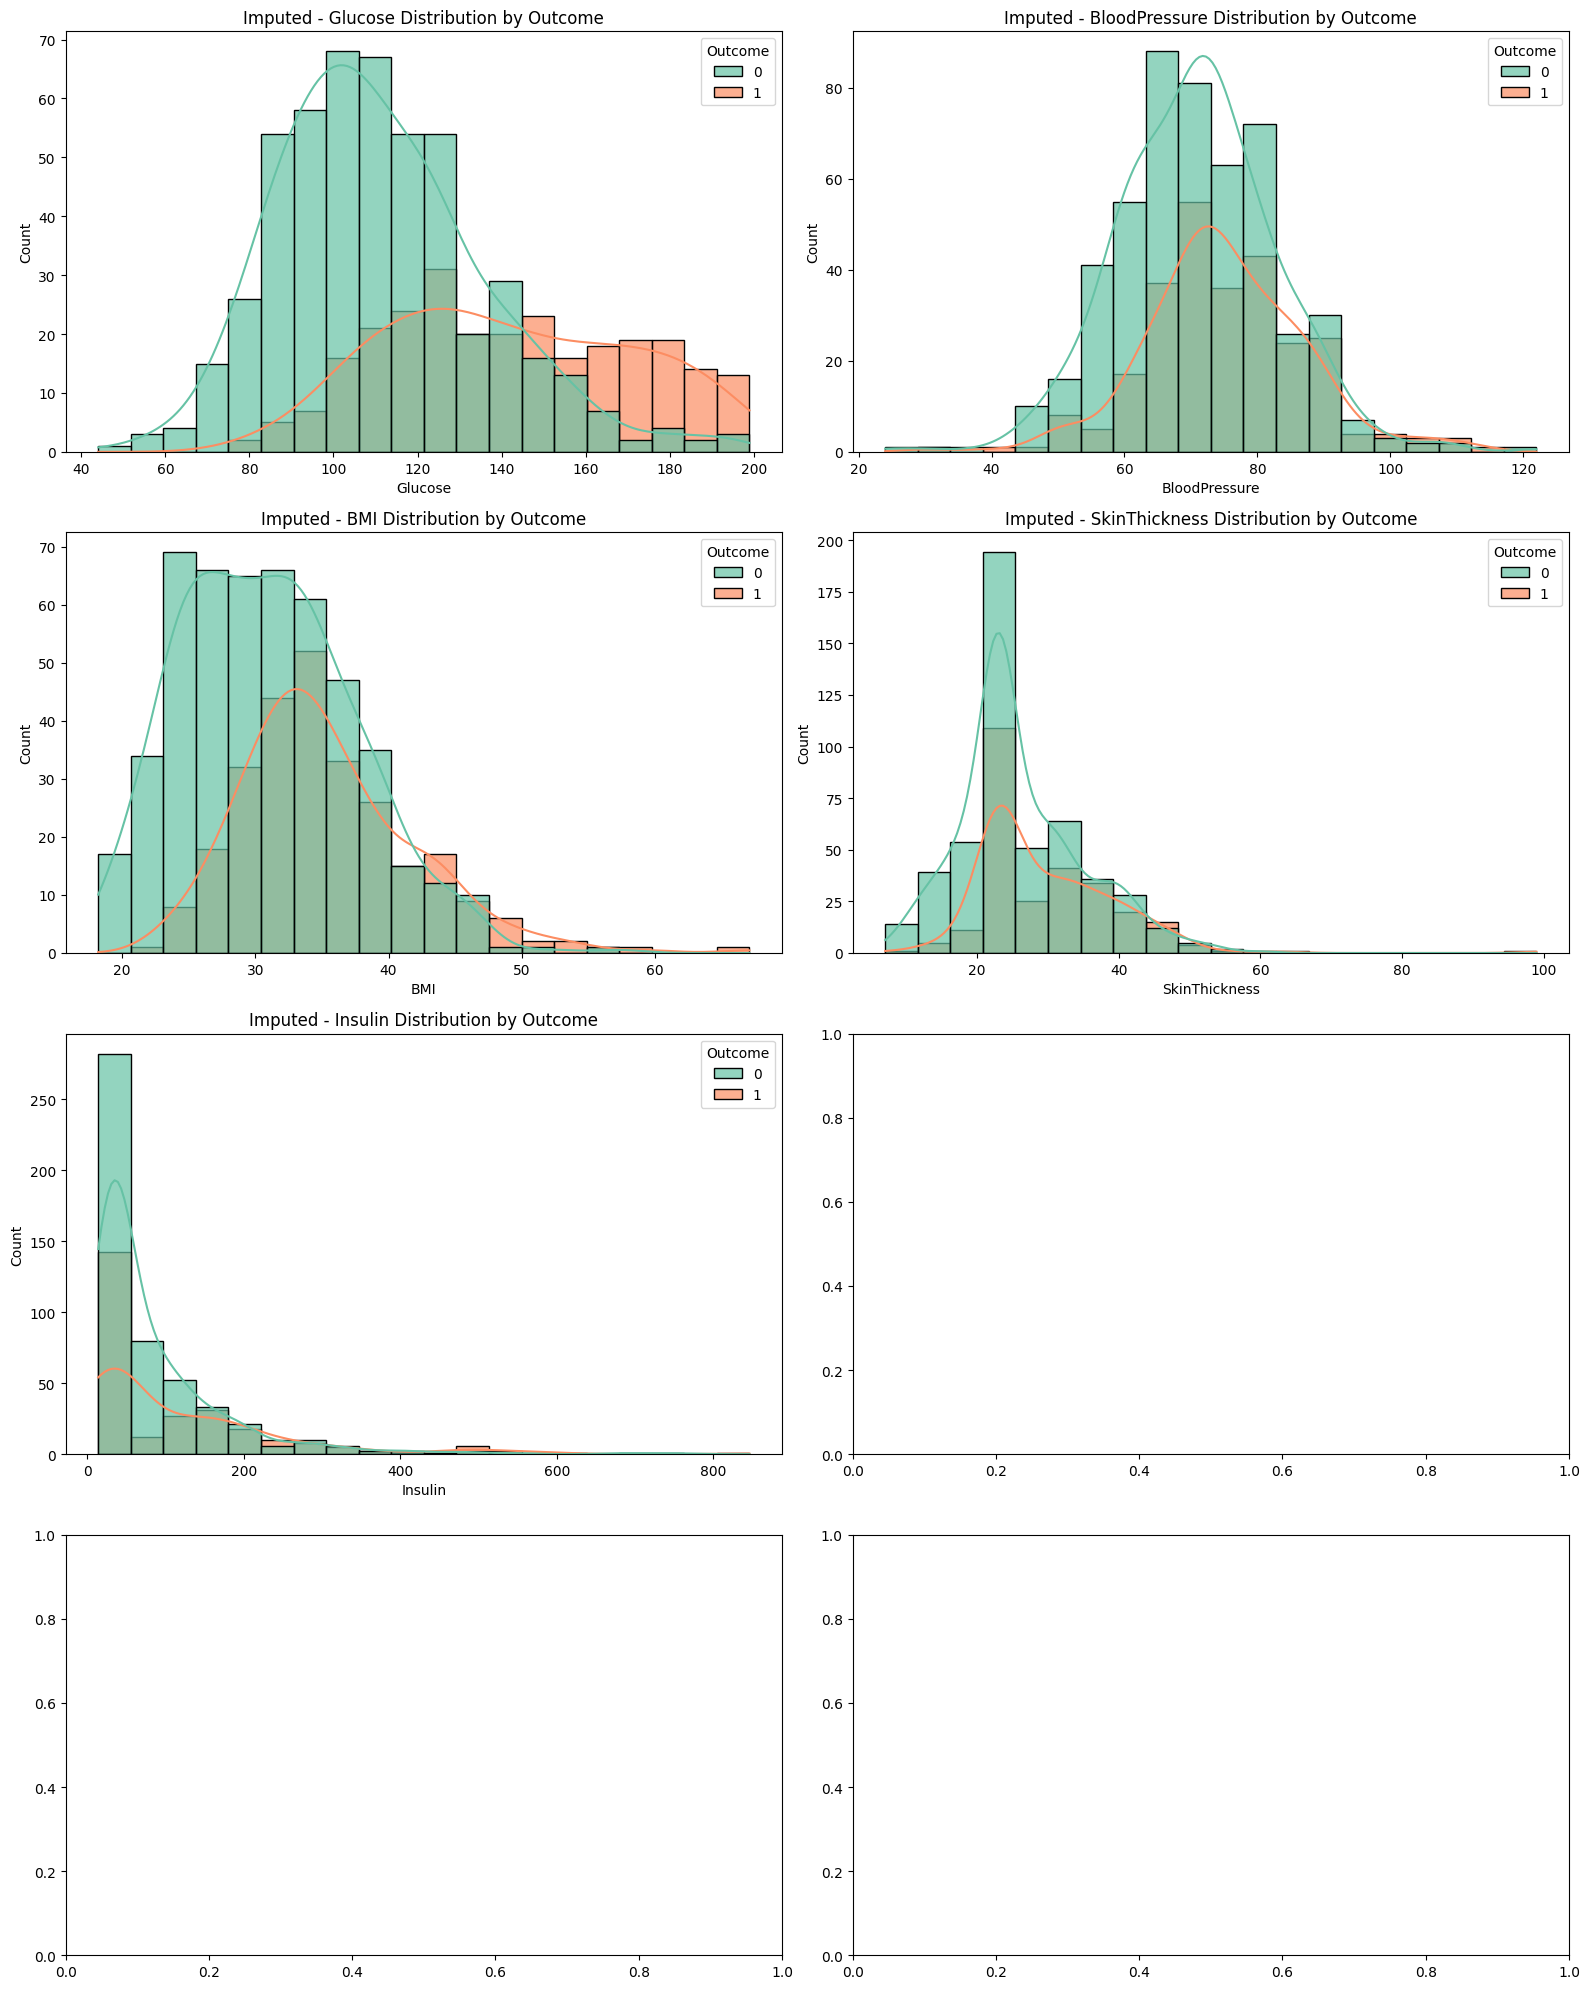

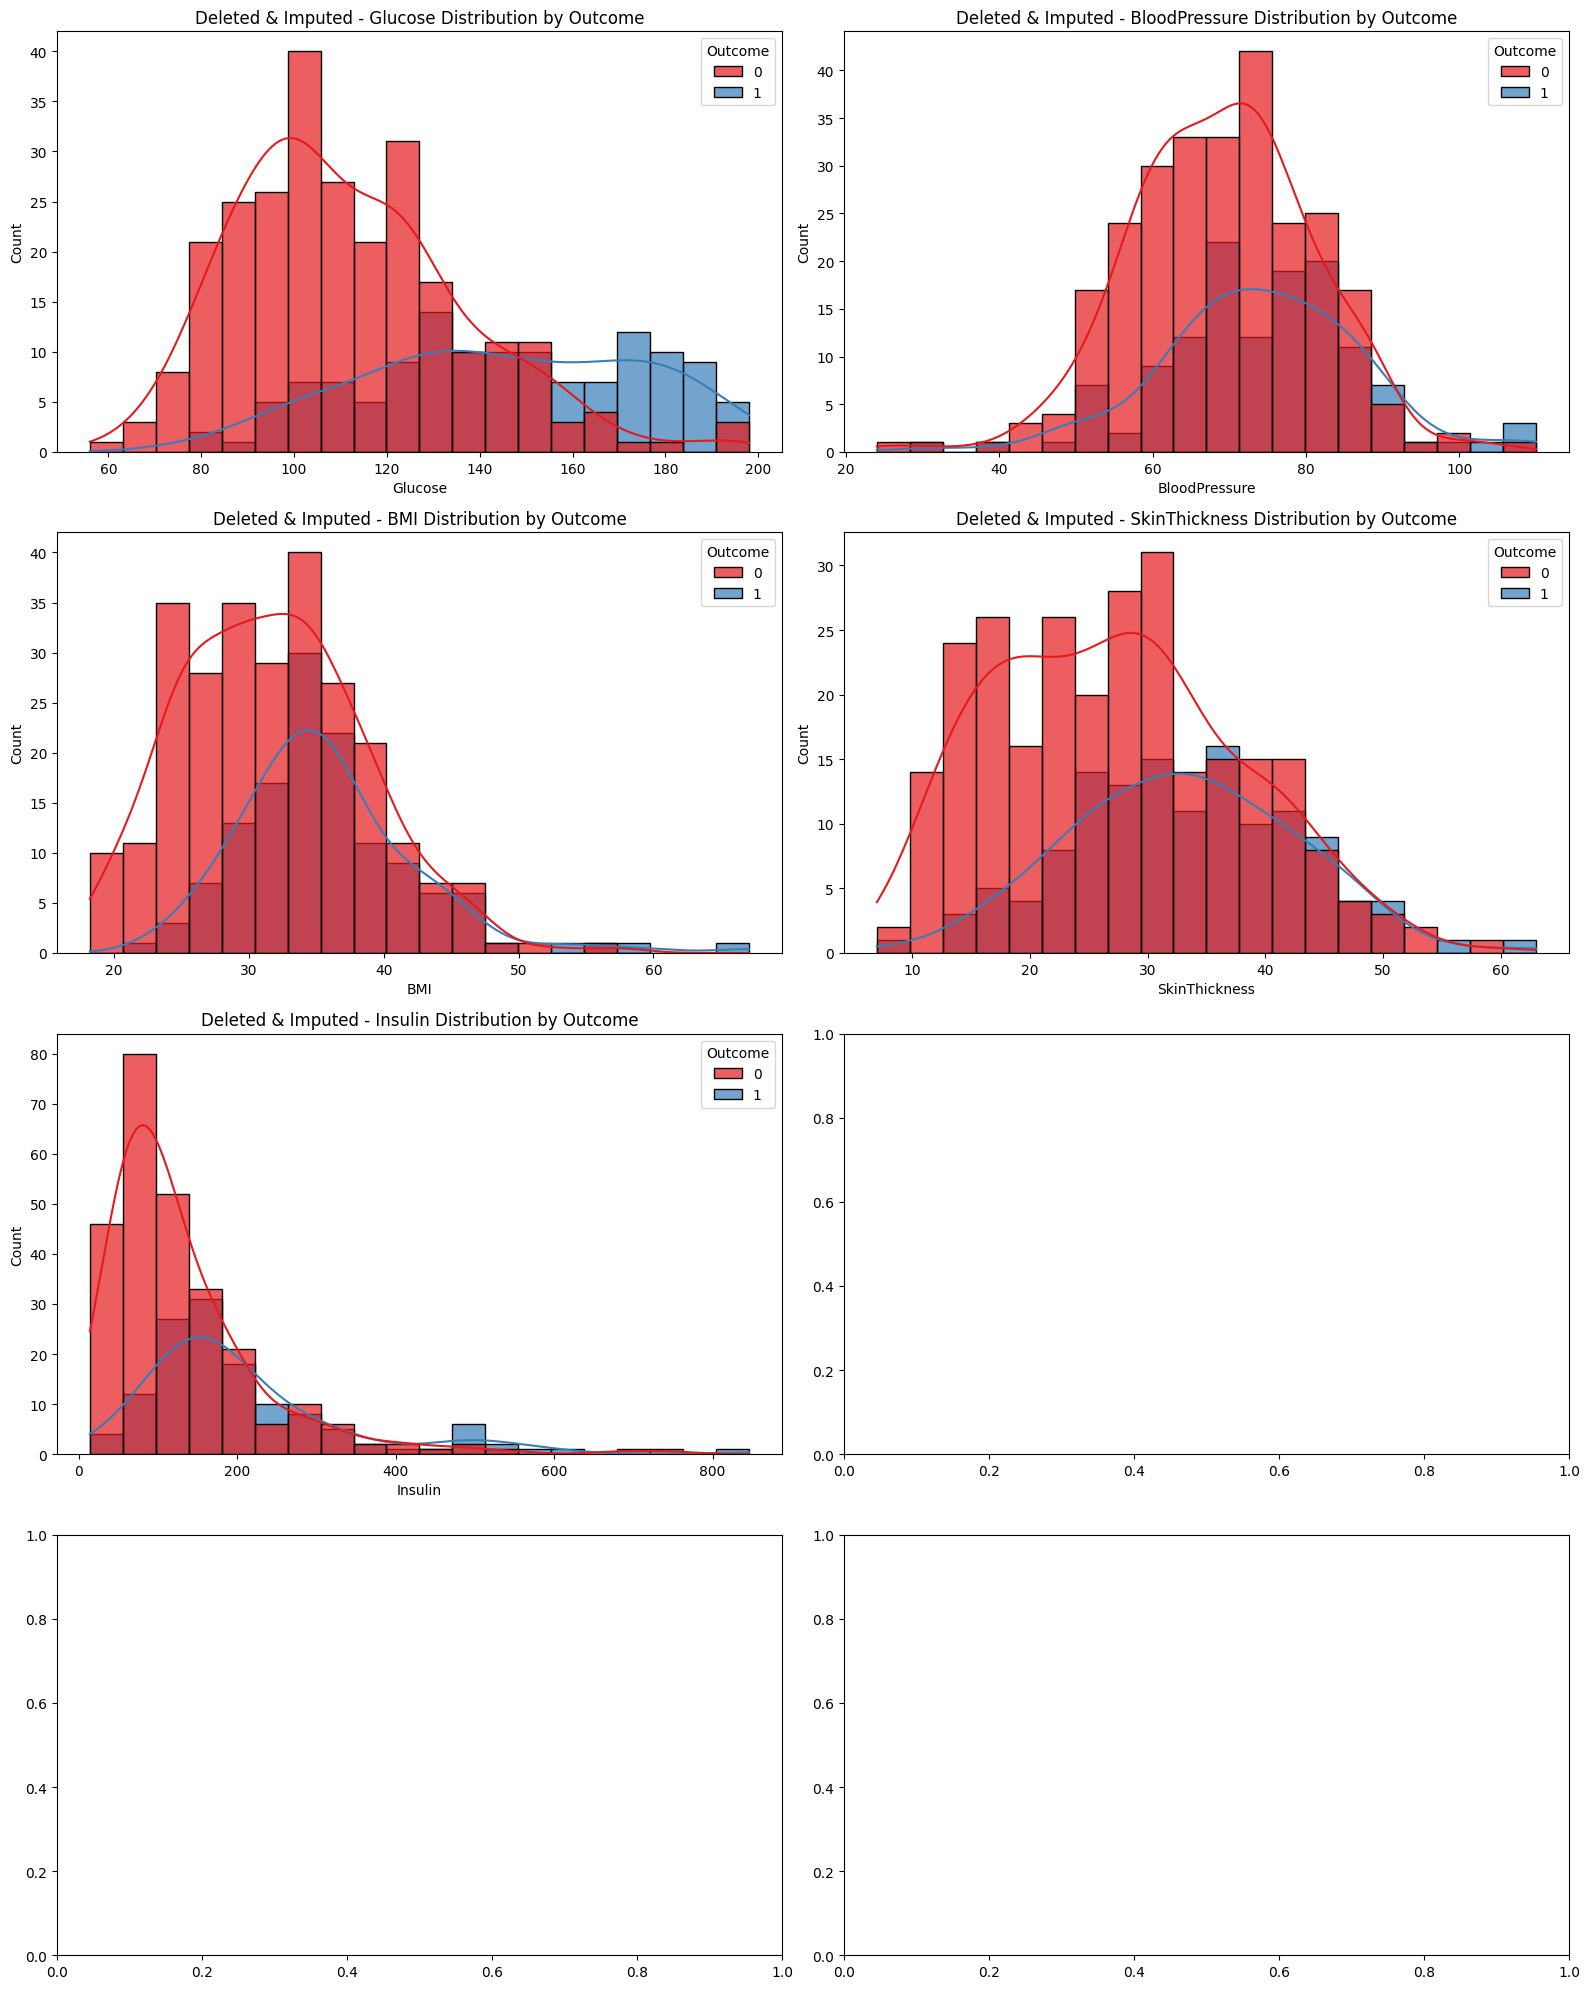

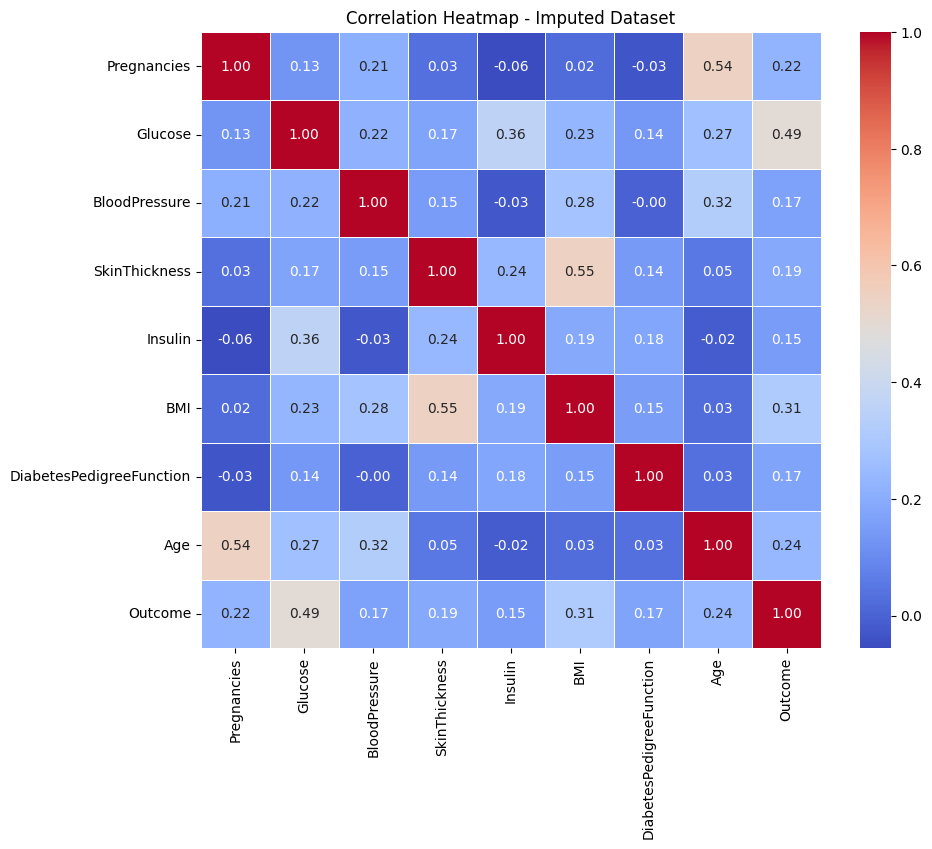

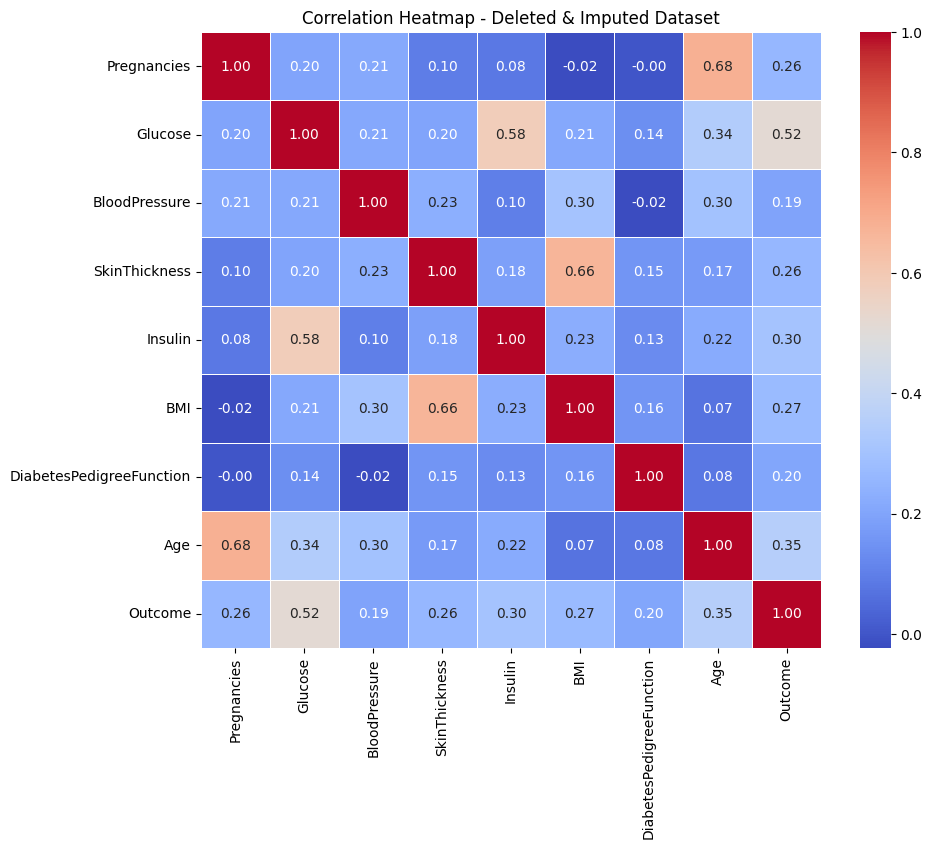

In [ ]:
# Histograma con KDE para la versión imputada
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(data_imputed, x=col, hue='Outcome', kde=True, palette='Set2', bins=20, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'Imputed - {col} Distribution by Outcome')
plt.tight_layout()
plt.show()

# Histograma con KDE para la versión eliminada e imputada
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(data_deleted_then_imputed, x=col, hue='Outcome', kde=True, palette='Set1', bins=20, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'Deleted & Imputed - {col} Distribution by Outcome')
plt.tight_layout()
plt.show()

# Heatmaps de correlación para cada versión del dataset

# Versión imputada
plt.figure(figsize=(10, 8))
sns.heatmap(data_imputed.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Imputed Dataset')
plt.show()

# Versión eliminada e imputada
plt.figure(figsize=(10, 8))
sns.heatmap(data_deleted_then_imputed.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Deleted & Imputed Dataset')
plt.show()


------------------

En esta etapa del proyecto, realizamos el tratamiento de los valores 0 en ciertas columnas del dataset, imputamos los valores faltantes y eliminamos columnas que no aportaban valor significativo al modelo. El objetivo fue preparar los datos para que fueran más adecuados para el análisis y la construcción del modelo predictivo.

### Acciones Realizadas:

##### Reemplazo de ceros por NaN en columnas seleccionadas:

* ¿Por qué?: Sabemos que ciertos valores como 0 en variables como Glucose, BloodPressure, y BMI no tienen sentido clínicamente (por ejemplo, no se espera que un paciente tenga un nivel de glucosa de 0). Estos ceros fueron reemplazados por NaN para luego ser imputados.

##### Imputación de valores faltantes:
* Glucose: Se imputó con la media de los valores existentes. La glucosa es una variable crucial para el diagnóstico de diabetes, y la media es una elección adecuada ya que los valores faltantes son pocos (solo 5).
* BloodPressure: Se imputó con el valor cuya proporción de Outcome = 1 (diabetes) era más cercana a la media de Outcome en el dataset. Esta decisión se tomó porque, en general, los valores de presión arterial tienen una relación moderada con el diagnóstico de diabetes, y al imputar de esta manera, conservamos la estructura de la distribución original sin afectar demasiado las proporciones.
* BMI: También se imputó con la media, ya que tiene pocos valores faltantes y es una medida directamente relacionada con el diagnóstico de diabetes.
* DiabetesPedigreeFunction no fue necesario imputarlo, ya que según el análisis previo, no hay ceros en esta columna.

##### Eliminación de columnas Insulin y SkinThickness:

* ¿Por qué?: Insulin y SkinThickness tenían una gran cantidad de ceros, lo cual es indicativo de datos faltantes. A pesar de ser variables que podrían ser relevantes, su relación con el Outcome es débil, con correlaciones bajas. Además, los valores atípicos (outliers) en estas columnas eran numerosos y dificultaban un análisis confiable.
Decidimos eliminarlas en lugar de imputarlas, ya que su aporte a la predicción parecía limitado, y su alta proporción de valores faltantes podría distorsionar el modelo.

### Manejo de outliers:
Decidimos no eliminar los outliers o valores extremos en las variables. Esto se debe a que, en muchos casos, los valores extremos pueden estar relacionados con el diagnóstico de diabetes y no necesariamente son errores o datos que deban ser descartados. Por ejemplo, un índice de masa corporal (BMI) muy alto podría estar indicando un caso grave de diabetes. De esta manera, decidimos dejar los outliers en su lugar y no intervenir, ya que su eliminación podría llevar a la pérdida de información valiosa para la predicción.

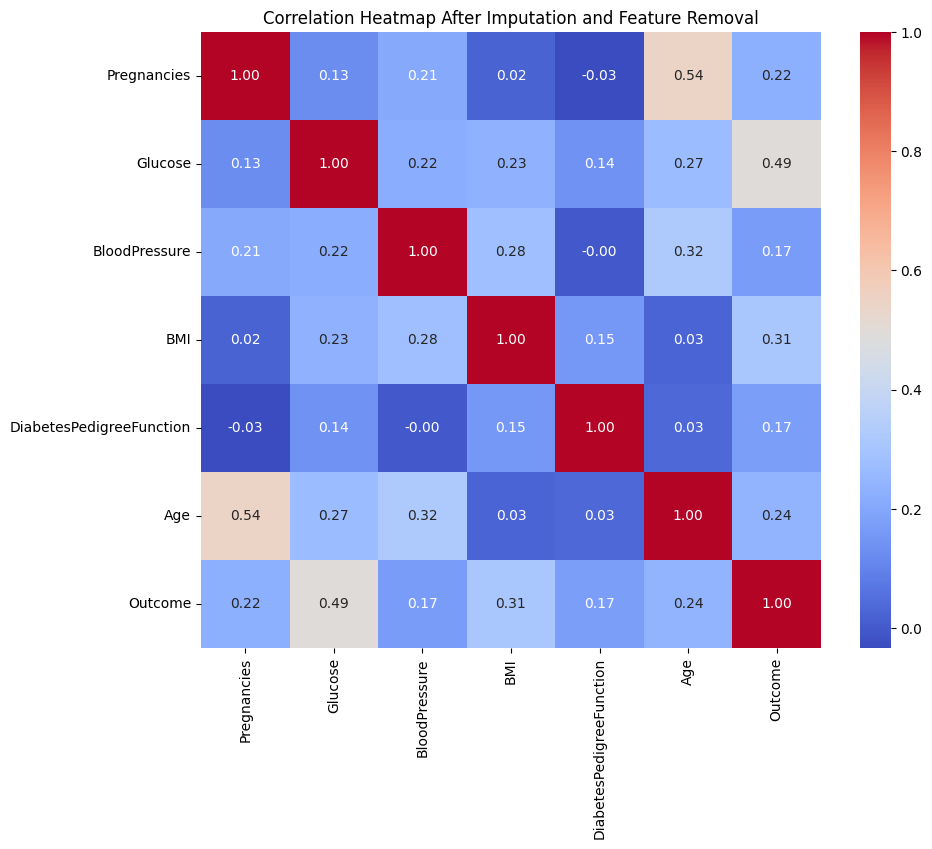

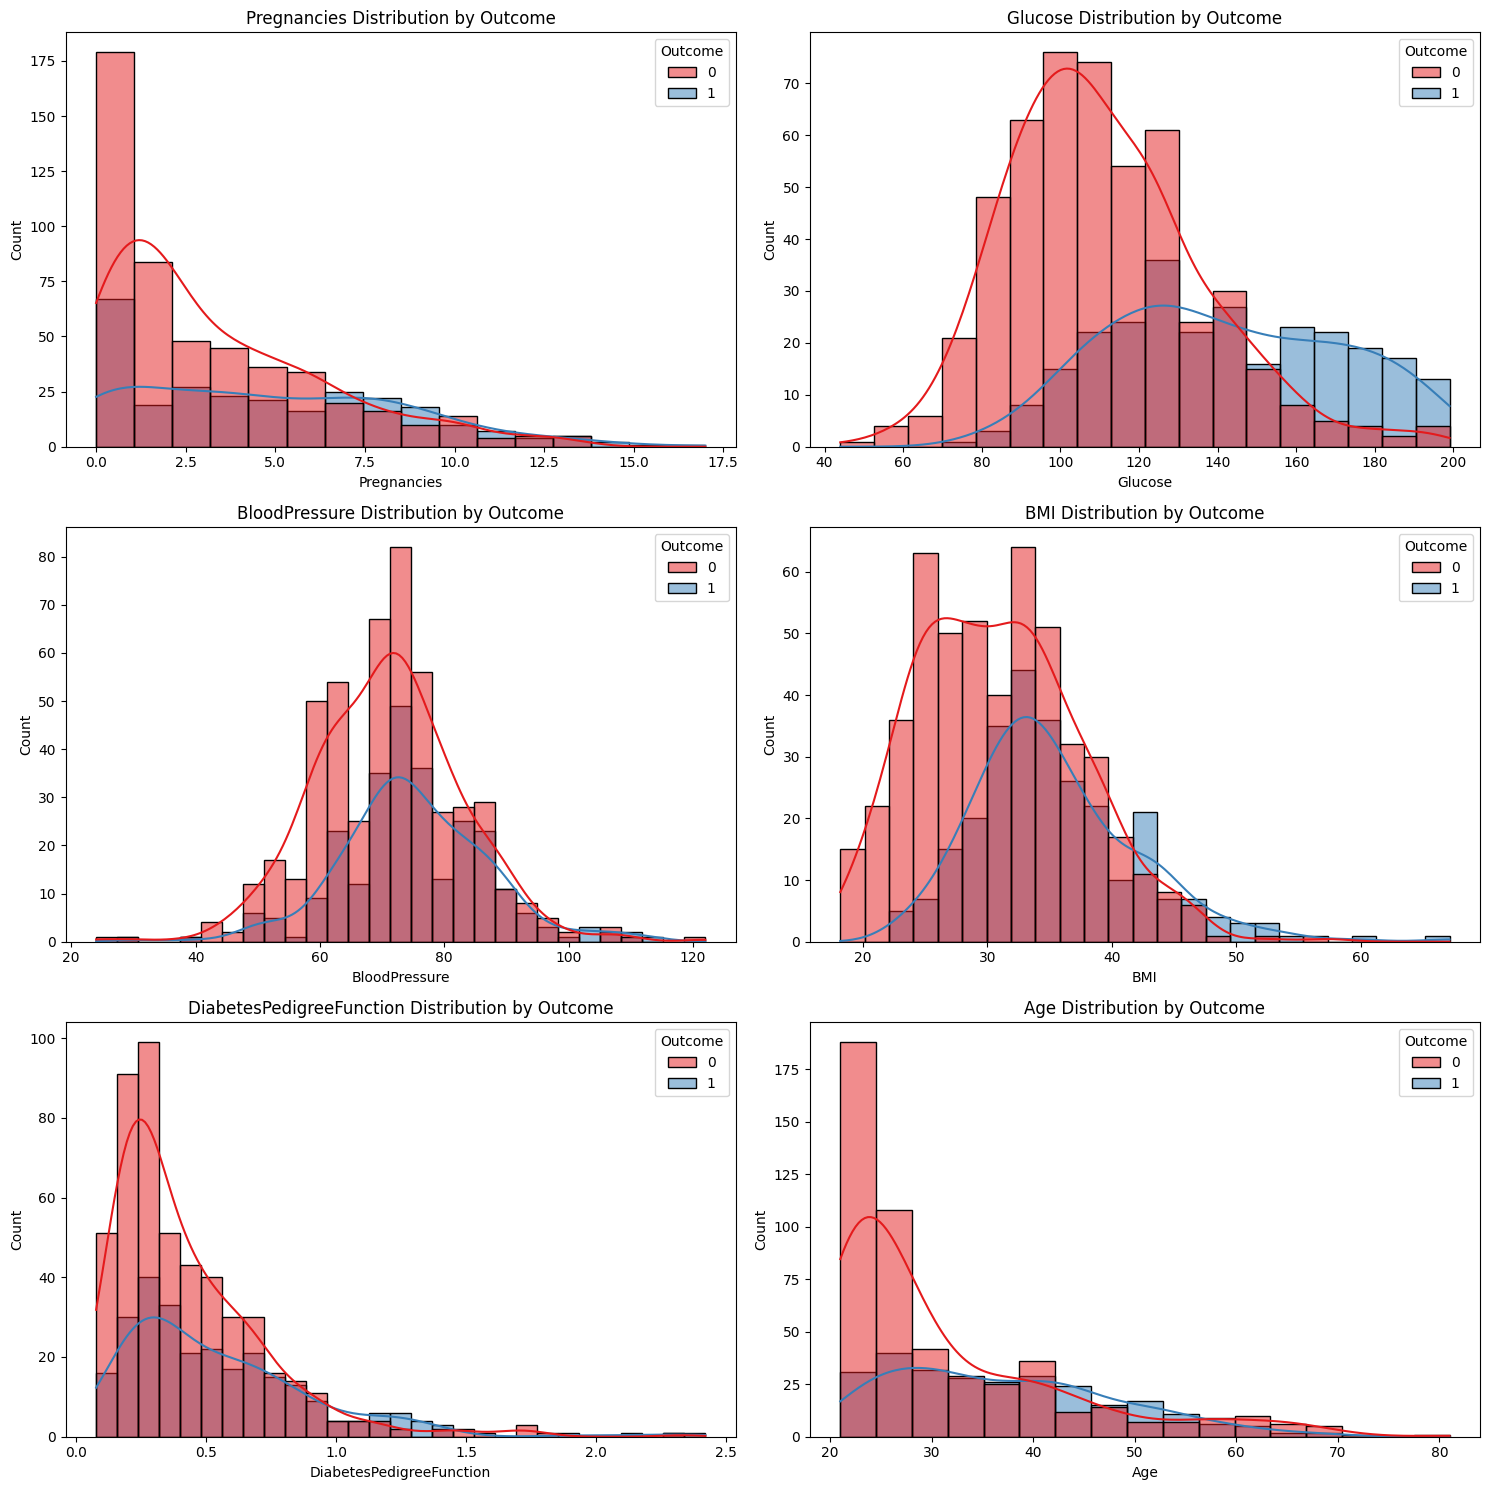

<ipython-input-10-f99fe14aa668>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Outcome', y=var, ax=axes[i], palette='Set2')
<ipython-input-10-f99fe14aa668>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Outcome', y=var, ax=axes[i], palette='Set2')
<ipython-input-10-f99fe14aa668>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Outcome', y=var, ax=axes[i], palette='Set2')
<ipython-input-10-f99fe14aa668>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

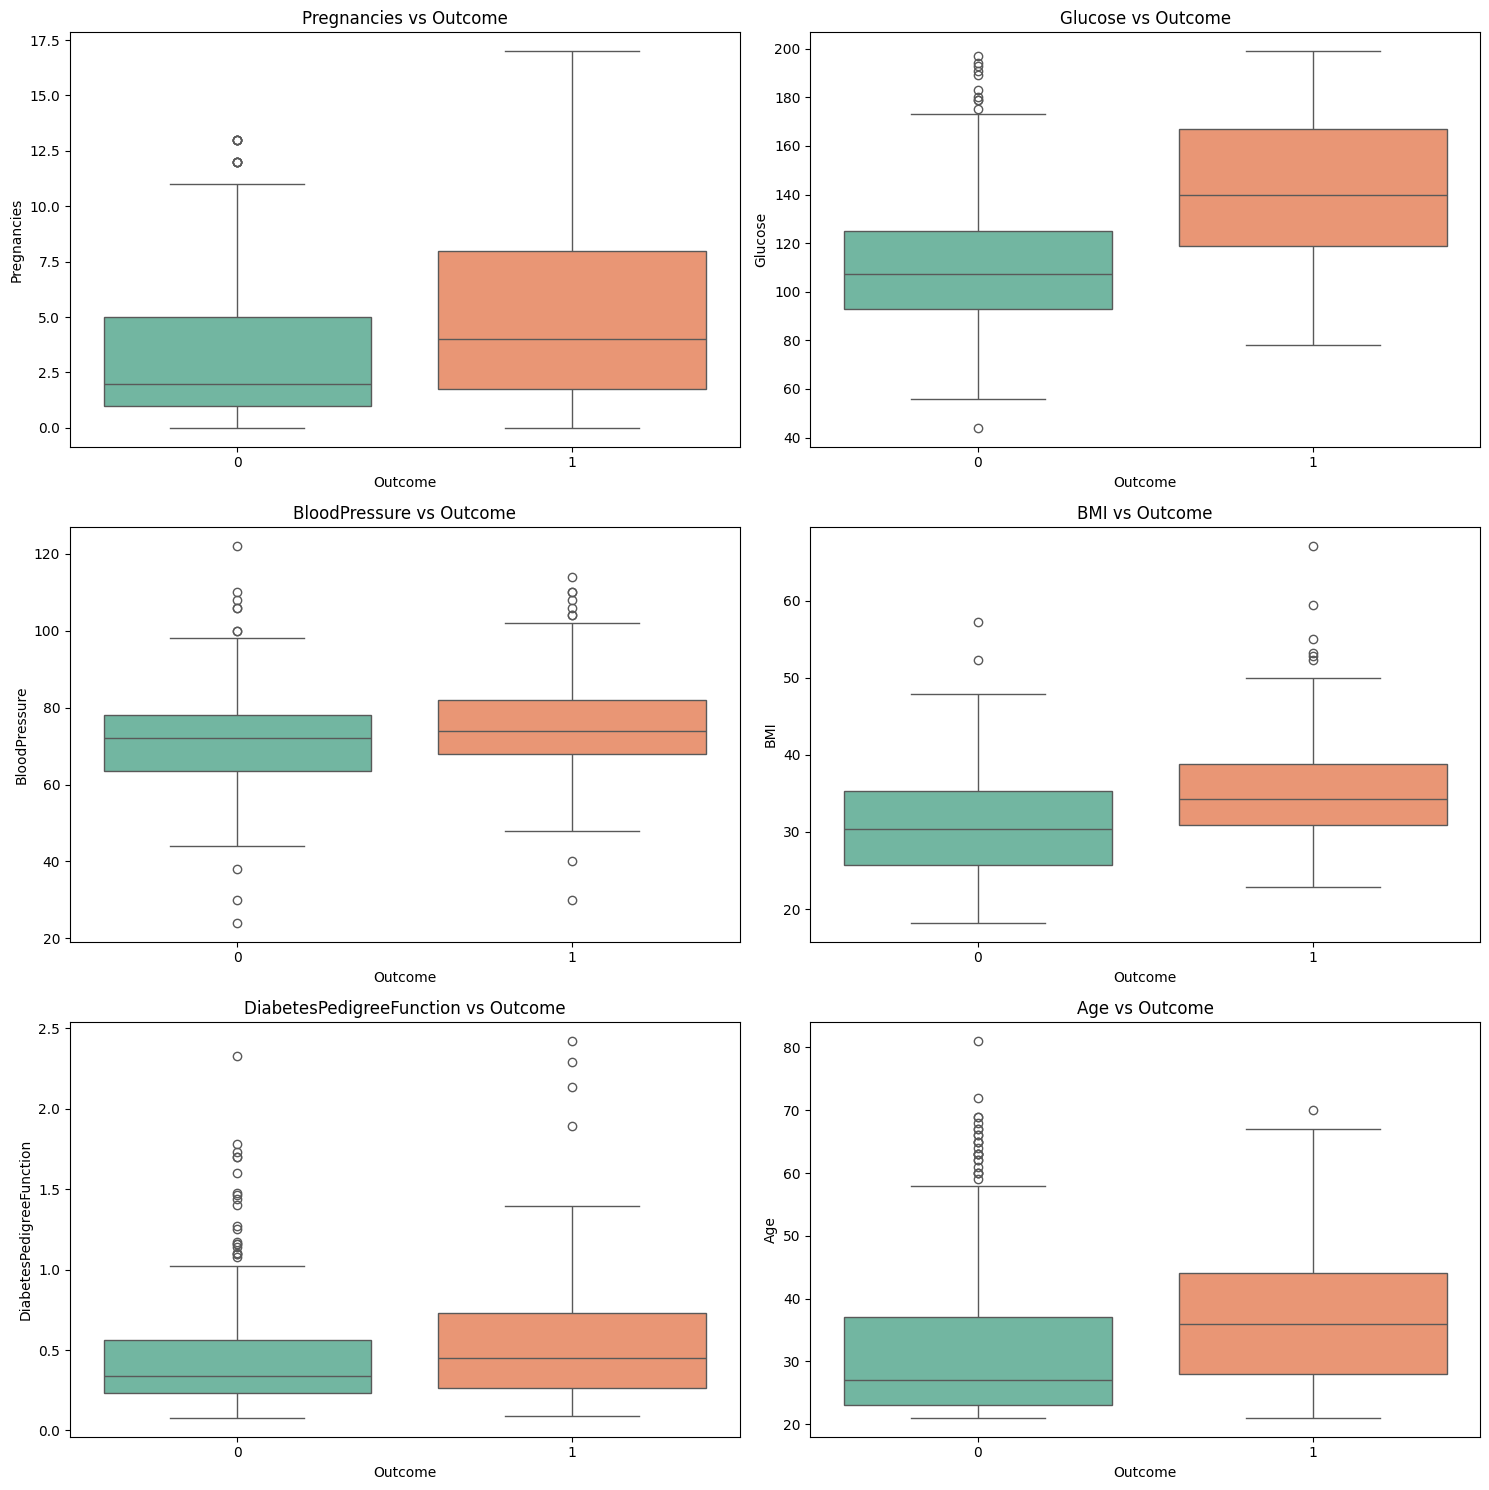

   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6    148.0           72.0  33.6                     0.627   50   
1            1     85.0           66.0  26.6                     0.351   31   
2            8    183.0           64.0  23.3                     0.672   32   
3            1     89.0           66.0  28.1                     0.167   21   
4            0    137.0           40.0  43.1                     2.288   33   

   Outcome  
0        1  
1        0  
2        1  
3        0  
4        1  


In [ ]:
# Reemplazar los valores 0 por NaN en las columnas seleccionadas
data['Glucose'] = data['Glucose'].replace(0, np.nan)
data['BloodPressure'] = data['BloodPressure'].replace(0, np.nan)
data['BMI'] = data['BMI'].replace(0, np.nan)

# Imputar 'Glucose' por la media
glucose_mean = data['Glucose'].mean()
data['Glucose'] = data['Glucose'].fillna(glucose_mean)

# Imputar 'BloodPressure' por el valor cuya proporción de Outcome=1 sea más similar
bp_proportion = data[data['BloodPressure'].notnull()].groupby('BloodPressure')['Outcome'].mean()
bp_closest_value = (bp_proportion - data['Outcome'].mean()).abs().idxmin()
data['BloodPressure'] = data['BloodPressure'].fillna(bp_closest_value)

# Eliminar las columnas 'Insulin' y 'SkinThickness'
data.drop(columns=['Insulin', 'SkinThickness'], inplace=True)

# Imputar 'BMI' por la media
bmi_mean = data['BMI'].mean()
data['BMI'] = data['BMI'].fillna(bmi_mean)

# No imputar 'DiabetesPedigreeFunction' porque no hay 0s según el gráfico

# Graficar para visualizar los resultados

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap After Imputation and Feature Removal')
plt.show()

# Distribuciones de cada variable por Outcome
variables = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(data=data, x=var, hue='Outcome', kde=True, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{var} Distribution by Outcome')

plt.tight_layout()
plt.show()

# Boxplots de las variables por Outcome
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(data=data, x='Outcome', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} vs Outcome')

plt.tight_layout()
plt.show()

# Verificar el dataset
print(data.head())

### Resultados Observados Después de la Imputación y Eliminación:

##### Matriz de Correlación:
* Después de la imputación y eliminación de columnas, realizamos un análisis de correlación nuevamente. La matriz de correlación muestra cómo las variables se relacionan entre sí y con el Outcome. La Glucose sigue siendo la variable más correlacionada con Outcome, mientras que Insulin y SkinThickness tienen correlaciones bajas, lo que valida la decisión de eliminarlas.

##### Distribución de las Características:
* Los histogramas y boxplots muestran cómo las variables se distribuyen por Outcome. Las distribuciones de Glucose, BMI y Age siguen mostrando patrones interesantes, con diferencias claras entre los valores de Outcome = 0 y Outcome = 1. En cambio, las distribuciones de BloodPressure y DiabetesPedigreeFunction son más homogéneas.


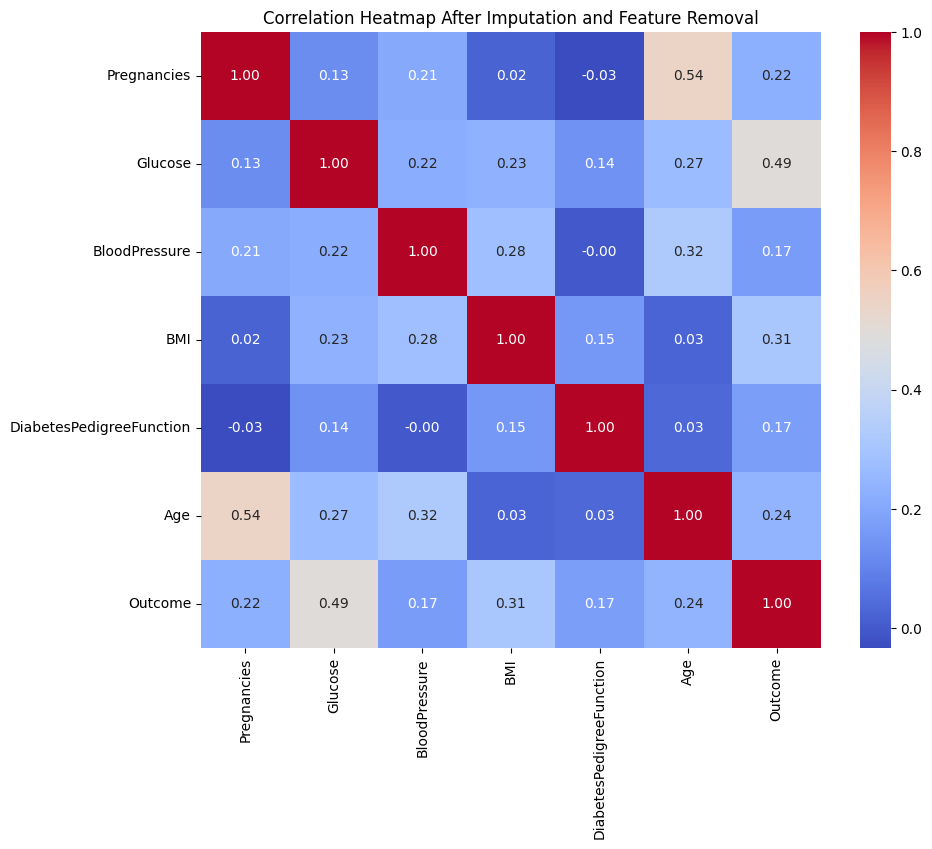

<ipython-input-11-e57c886d2edf>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data[col], palette="Set2")  # Ahora solo las columnas presentes
<ipython-input-11-e57c886d2edf>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data[col], palette="Set2")  # Ahora solo las columnas presentes
<ipython-input-11-e57c886d2edf>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data[col], palette="Set2")  # Ahora solo las columnas presentes
<ipython-input-11-e57c886d2edf>:17: FutureWarning: 

Passing `palette` without assigning `hue` is depre

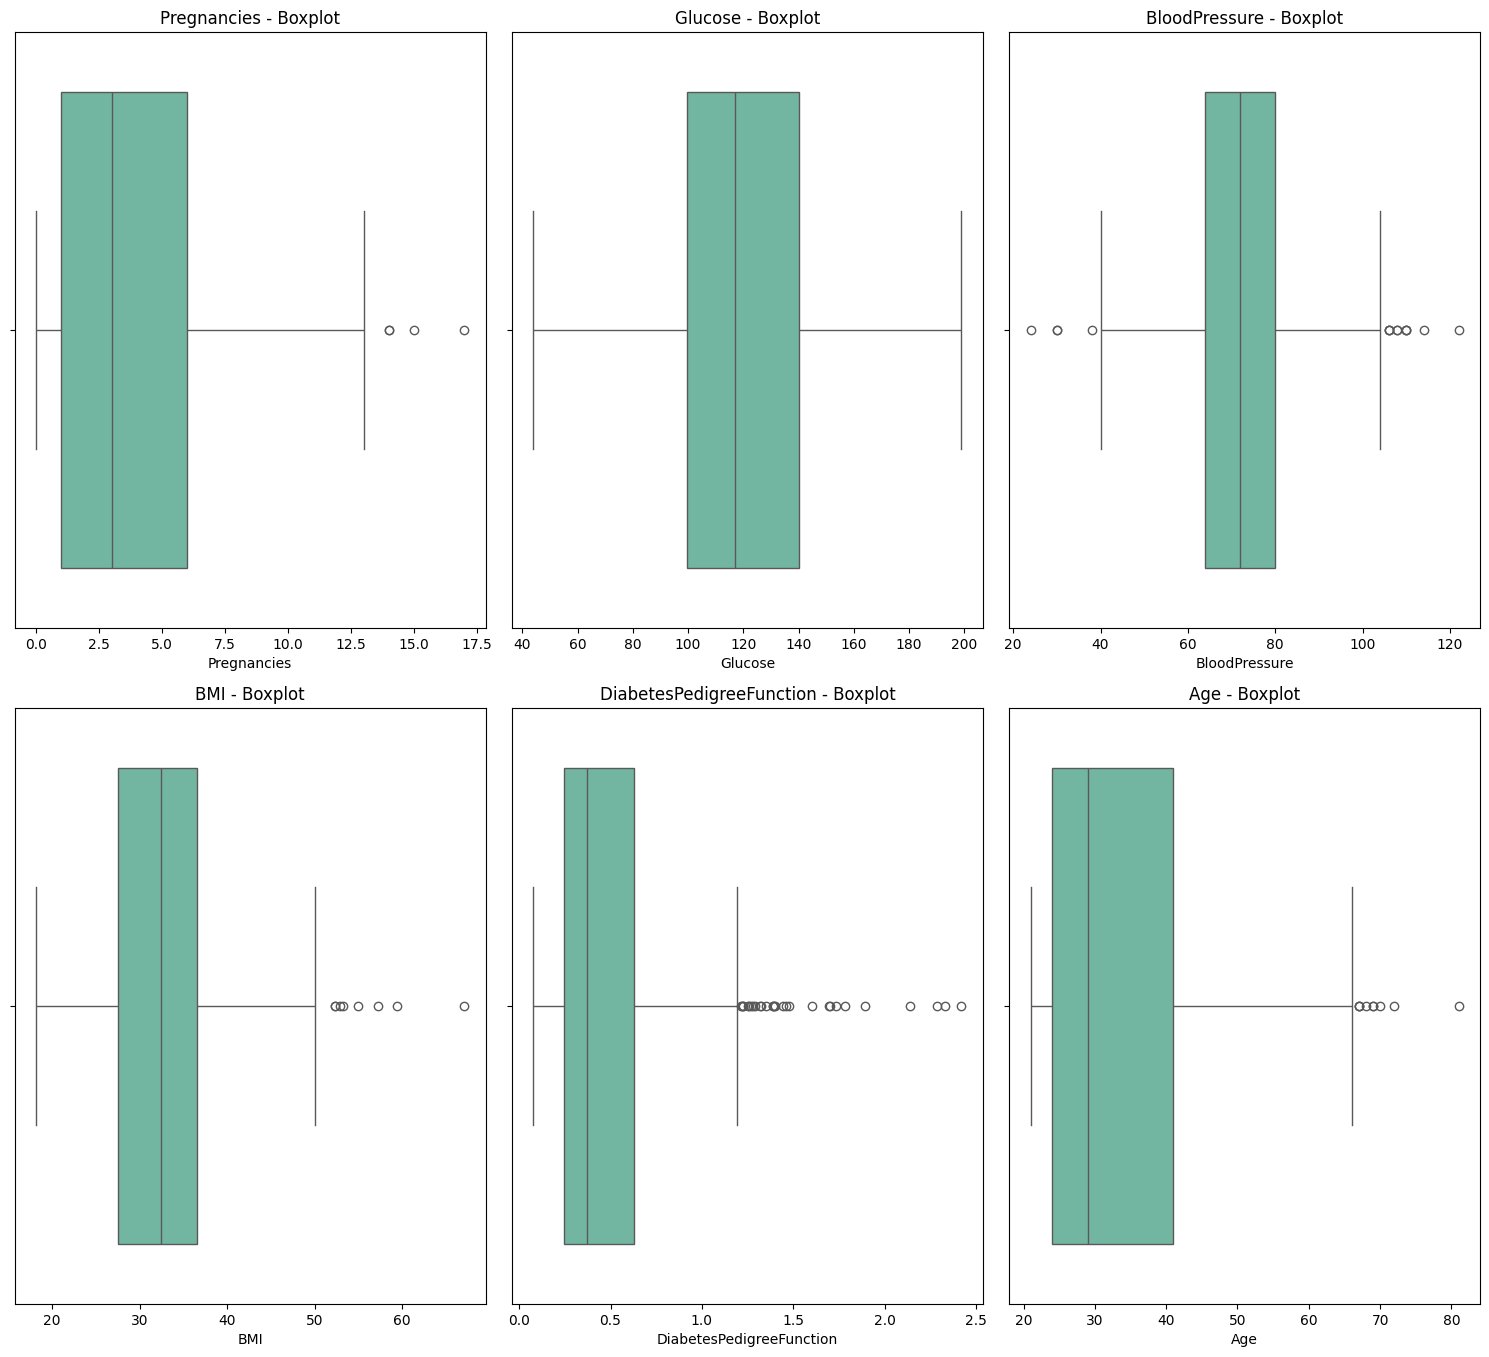

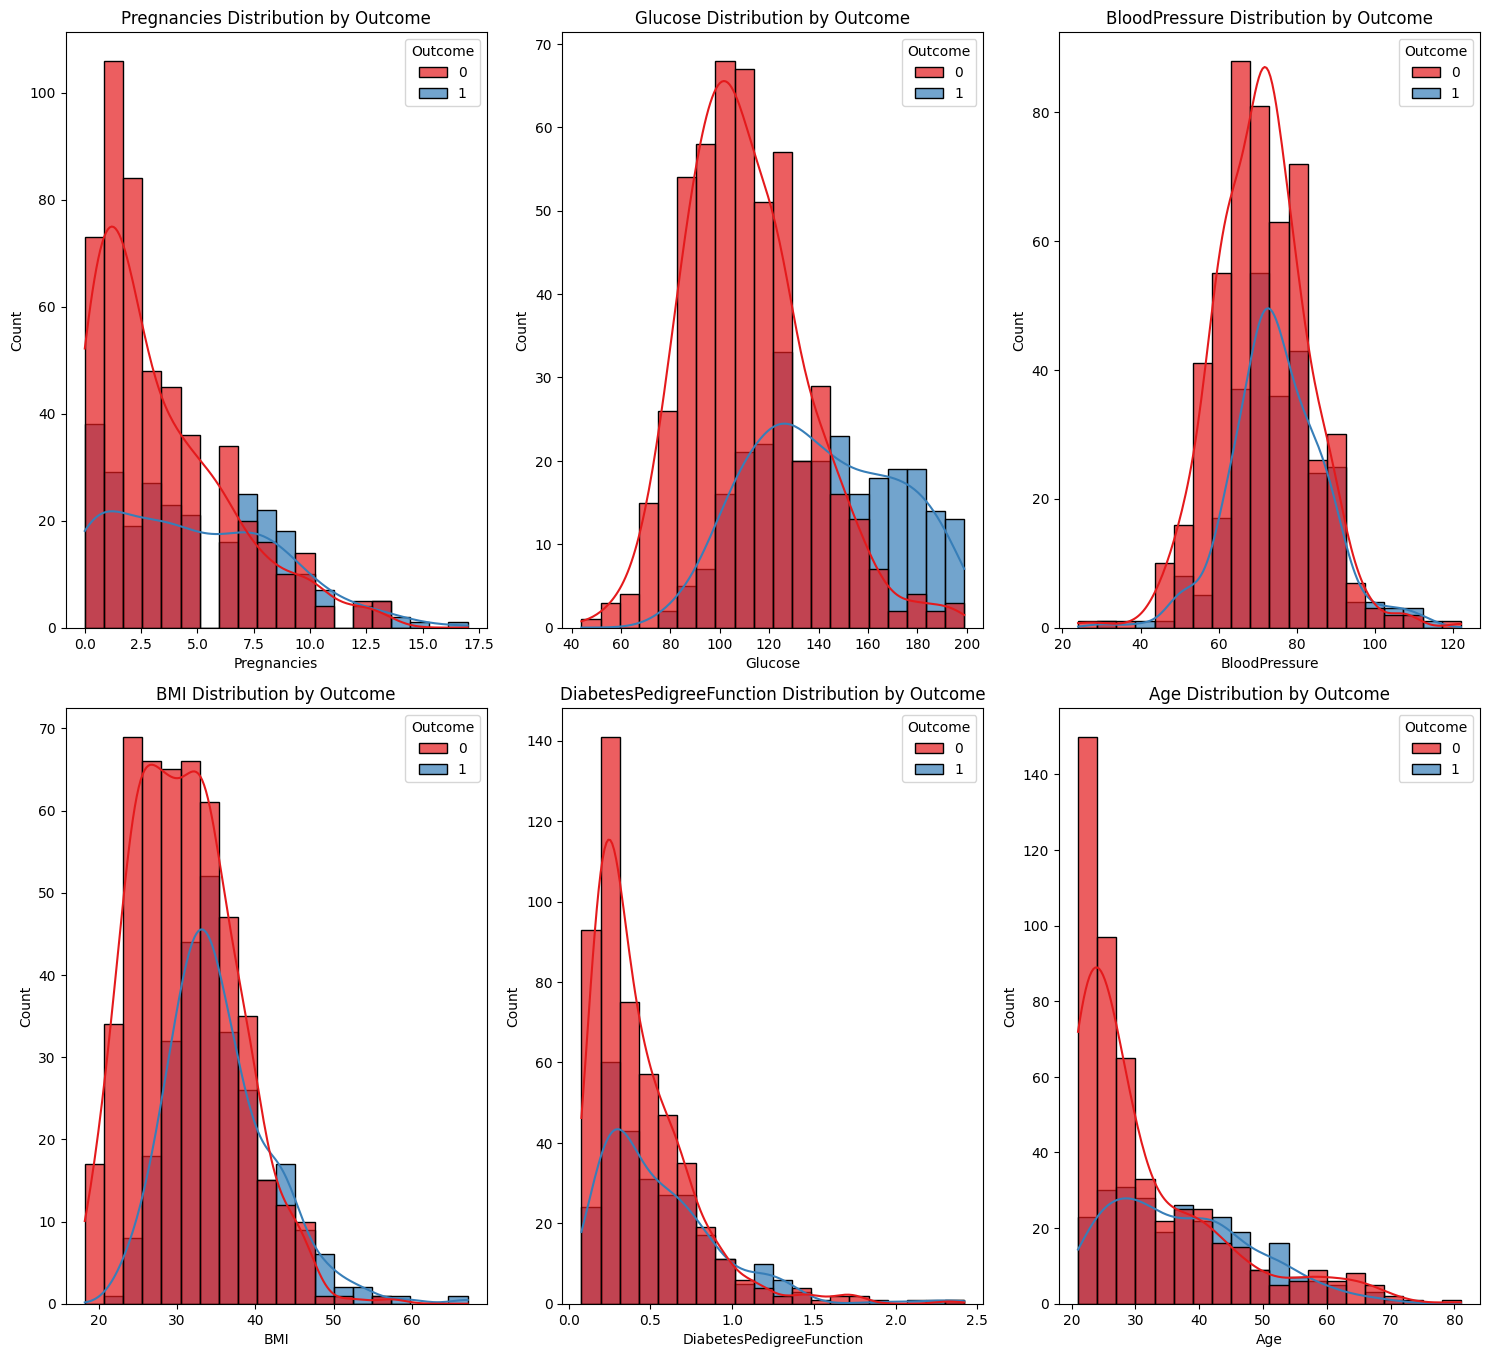

<ipython-input-11-e57c886d2edf>:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-11-e57c886d2edf>:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-11-e57c886d2edf>:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-11-e57c886d2edf>:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
<ipython-input-11-e57c886d2edf>:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.valu

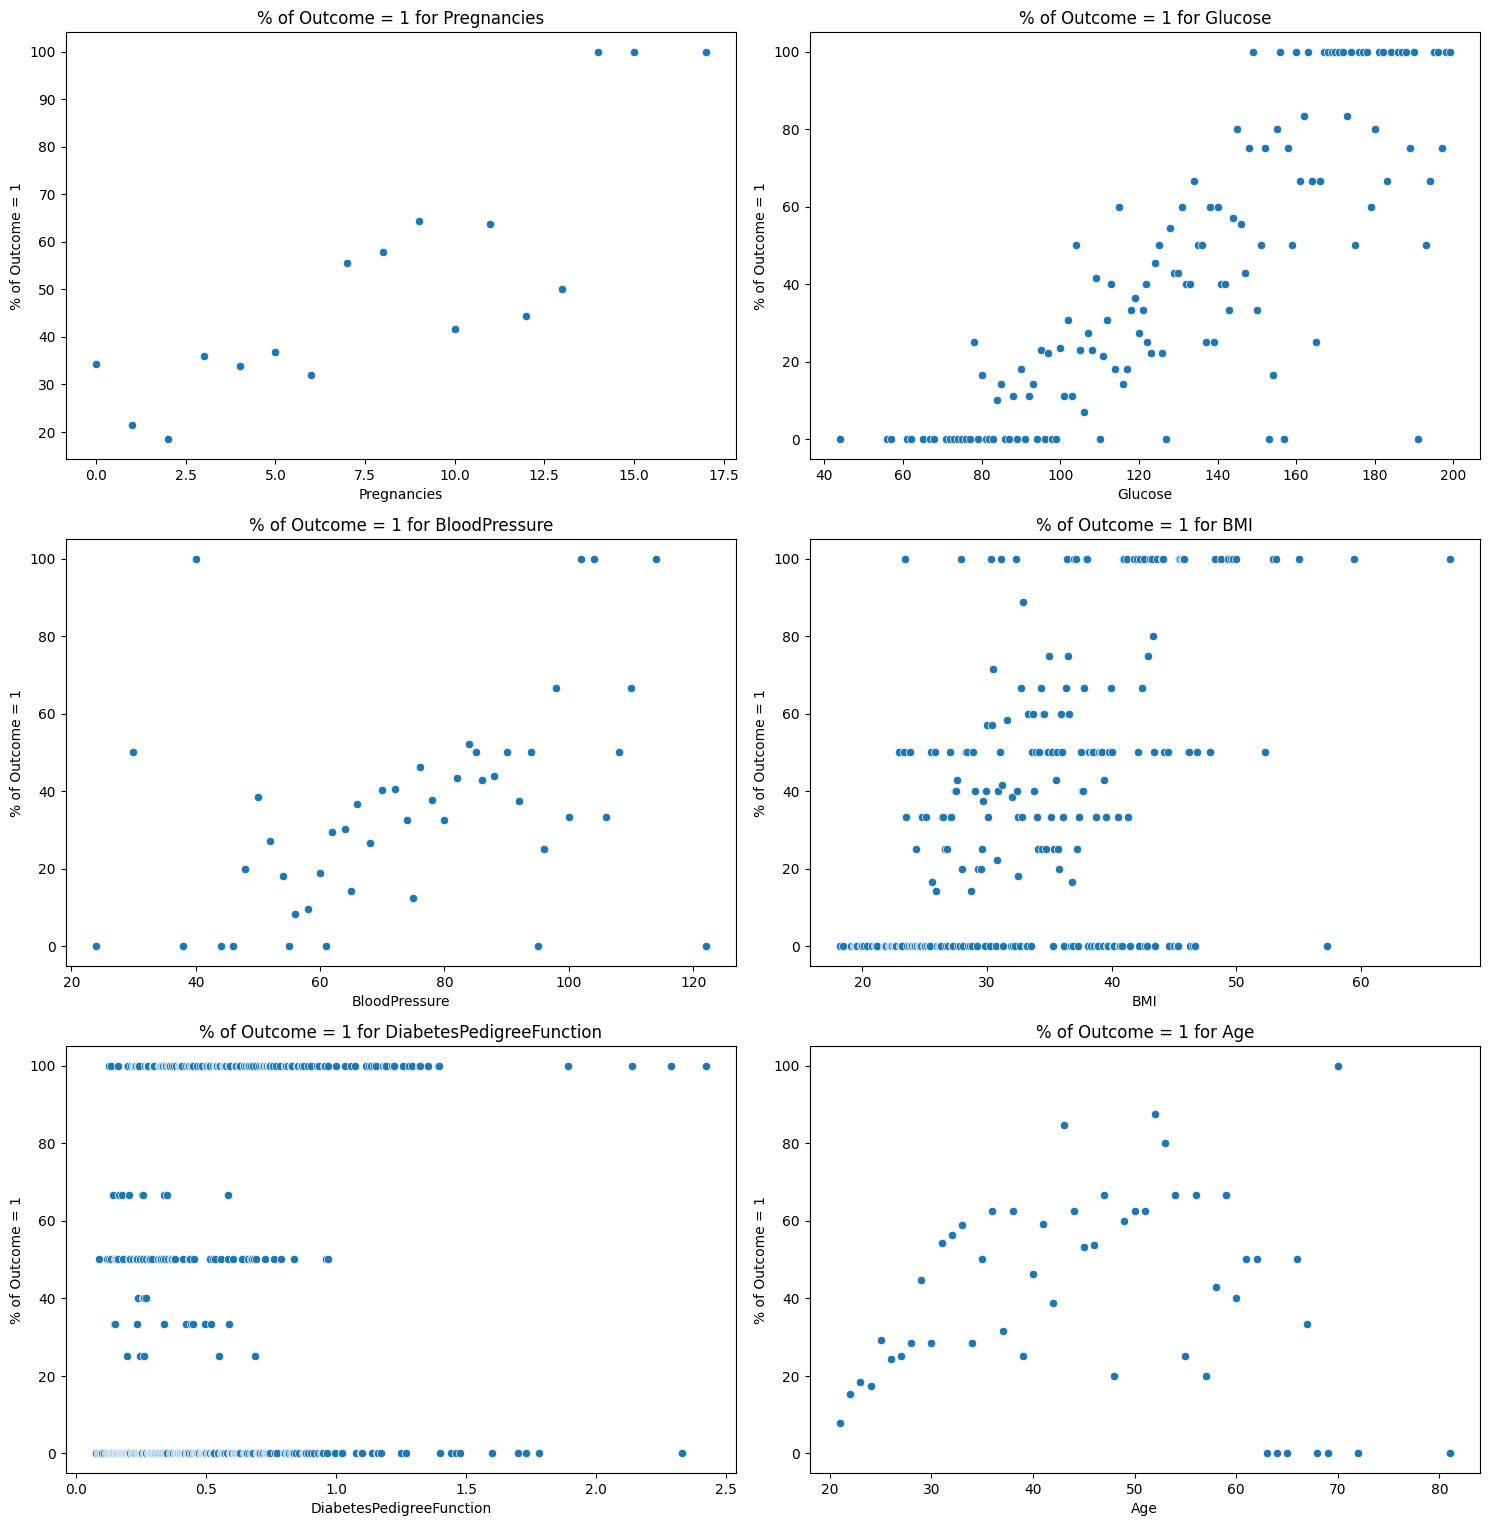

In [ ]:
# Columnas que no fueron eliminadas
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Graficar los resultados

# 1. Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap After Imputation and Feature Removal')
plt.show()

# 2. Boxplots de las variables vs Outcome
plt.figure(figsize=(15, 20))

for i, col in enumerate(columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data[col], palette="Set2")
    plt.title(f'{col} - Boxplot')
    plt.tight_layout()

plt.show()

# 3. Histogramas de las distribuciones por Outcome
plt.figure(figsize=(15, 20))

for i, col in enumerate(columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data, x=col, hue='Outcome', kde=True, palette='Set1', bins=20, alpha=0.7)
    plt.title(f'{col} Distribution by Outcome')
    plt.tight_layout()

plt.show()

# 4. Scatterplots del porcentaje de Outcome = 1 para cada feature
plt.figure(figsize=(15, 20))

for i, feature in enumerate(columns, 1):
    plt.subplot(4, 2, i)

    # Calcular el % de outcomes 1 para cada valor único del feature
    outcome_percentage = data.groupby(feature)['Outcome'].mean() * 100  # Porcentaje

    # Graficar el resultado
    sns.scatterplot(x=outcome_percentage.index, y=outcome_percentage.values, palette='Set1')
    plt.title(f'% of Outcome = 1 for {feature}')
    plt.xlabel(feature)
    plt.ylabel('% of Outcome = 1')
    plt.tight_layout()

plt.show()

-------------

En esta fase del proyecto, implementamos los modelos de Regresión Logística y Random Forest para predecir el Outcome (diabetes). Previo al entrenamiento, estandarizamos los datos utilizando StandardScaler para mejorar el rendimiento de los modelos y evitar que las diferencias de escala entre las características afecten la precisión del modelo.

Elegimos Regresión Logística y Random Forest debido a su eficacia para problemas de clasificación binaria y su capacidad de manejar tanto características lineales como no lineales.

### Acciones Realizadas:

##### Estandarización de los Datos:
* Para que los modelos funcionen correctamente, especialmente aquellos que son sensibles a la escala como la Regresión Logística, estandarizamos las características utilizando StandardScaler. Esto asegura que cada característica tenga una media de 0 y una desviación estándar de 1, lo que ayuda a que el modelo no se vea influenciado por las diferencias de escala entre las variables.

##### División de los Datos:
* Utilizamos K-Fold Cross-Validation (con 5 pliegues) para dividir los datos en subconjuntos de entrenamiento y validación. Esto permite entrenar y evaluar el modelo múltiples veces con diferentes subconjuntos de datos, lo que mejora la fiabilidad de los resultados y evita el sobreajuste.

##### Entrenamiento de los Modelos:
* Regresión Logística: Se entrenó un modelo de regresión logística con el parámetro max_iter=1000 para garantizar la convergencia del modelo.
* Random Forest: Se entrenó un modelo de Random Forest con 100 estimadores y un valor fijo de random_state=42 para asegurar la reproducibilidad de los resultados.

##### Evaluación de Modelos:
* Usamos cross-validation para evaluar la precisión de ambos modelos. Esto proporcionó una medida más robusta del rendimiento, ya que se realiza en varios subconjuntos de los datos.
Además, evaluamos ambos modelos mediante:
* Métricas de desempeño como precision, recall y F1-score.
* Matriz de confusión para el último fold, que muestra cómo se clasificaron correctamente los casos de Outcome = 1 y Outcome = 0.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Estandarización de los datos
scaler = StandardScaler()
data_not_standardized = data.copy()
data[columns] = scaler.fit_transform(data[columns])

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
X = data.drop('Outcome', axis=1)  # Features
y = data['Outcome']  # Label

# Dividir en conjunto de entrenamiento y prueba usando K-Fold Cross-Validation (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. Inicializar los modelos
logreg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
def evaluate_model(model, X, y, cv):
    # Lista para guardar resultados
    accuracies = []
    class_reports = []
    confusion_matrices = []

    for train_index, val_index in cv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Hacer predicciones
        y_pred = model.predict(X_val)

        # Guardar las métricas
        accuracies.append(accuracy_score(y_val, y_pred))
        class_reports.append(classification_report(y_val, y_pred, output_dict=True))
        confusion_matrices.append(confusion_matrix(y_val, y_pred))

    return accuracies, class_reports, confusion_matrices

In [ ]:
# 2. Entrenar y evaluar el modelo de Regresión Logística con K-Fold Cross-Validation
cv_scores_logreg = cross_val_score(logreg, X, y, cv=kf, scoring='accuracy')
print("Cross-validated accuracy for Logistic Regression:", cv_scores_logreg.mean())

# Evaluar Regresión Logística
accuracies_logreg, reports_logreg, cm_logreg = evaluate_model(logreg, X, y, kf)

Cross-validated accuracy for Logistic Regression: 0.7669467787114845


In [ ]:
# 3. Entrenar y evaluar el modelo de Random Forest con K-Fold Cross-Validation
cv_scores_rf = cross_val_score(rf, X, y, cv=kf, scoring='accuracy')
print("Cross-validated accuracy for Random Forest:", cv_scores_rf.mean())

# Evaluar Random Forest
accuracies_rf, reports_rf, cm_rf = evaluate_model(rf, X, y, kf)

Cross-validated accuracy for Random Forest: 0.7864357864357864


In [ ]:
from sklearn.metrics import classification_report

# Función para extraer las métricas de 'Outcome=1' del classification report
def extract_metrics(report, label='1'):
    # Extraer las métricas 'precision', 'recall' y 'f1-score' para el 'Outcome=1'
    metrics = report.get(label, {})
    return [metrics.get('precision', 0), metrics.get('recall', 0), metrics.get('f1-score', 0)]

# Promediar las métricas para cada modelo (Logistic Regression y Random Forest)

# Para Logistic Regression
logreg_metrics = [extract_metrics(report) for report in reports_logreg]
logreg_avg_metrics = np.mean(logreg_metrics, axis=0)

# Para Random Forest
rf_metrics = [extract_metrics(report) for report in reports_rf]
rf_avg_metrics = np.mean(rf_metrics, axis=0)

# Mostrar los resultados promedio
print("Logistic Regression Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {logreg_avg_metrics[0]:.4f}")
print(f"Recall: {logreg_avg_metrics[1]:.4f}")
print(f"F1-Score: {logreg_avg_metrics[2]:.4f}")

print("\nRandom Forest Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {rf_avg_metrics[0]:.4f}")
print(f"Recall: {rf_avg_metrics[1]:.4f}")
print(f"F1-Score: {rf_avg_metrics[2]:.4f}")

# Matriz de Confusión para el último fold de ambos modelos
print("\nLogistic Regression Confusion Matrix (last fold):")
print(cm_logreg[-1])

print("\nRandom Forest Confusion Matrix (last fold):")
print(cm_rf[-1])

Logistic Regression Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7163
Recall: 0.5593
F1-Score: 0.6251

Random Forest Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7204
Recall: 0.6471
F1-Score: 0.6769

Logistic Regression Confusion Matrix (last fold):
[[85 10]
 [29 29]]

Random Forest Confusion Matrix (last fold):
[[83 12]
 [26 32]]


### Resultados Obtenidos:

#### Precision, Recall y F1-Score:

##### Regresión Logística:
* Precision: 0.7163
* Recall: 0.5593
* F1-Score: 0.6251

##### Random Forest:
* Precision: 0.7204
* Recall: 0.6471
* F1-Score: 0.6769

##### Conclusión:
Ambos modelos tienen una precisión similar, pero Random Forest tiene un recall más alto, lo que es relevante en el contexto de diagnóstico médico (queremos detectar tantos casos de Outcome = 1 como sea posible).

#### Matriz de Confusión:

##### Regresión Logística:
* [[85 10], [29 29]]
* El modelo clasifica correctamente 85 casos como Outcome = 0 y 29 casos como Outcome = 1, pero también comete 10 falsos positivos y 29 falsos negativos.

##### Random Forest:
* [[83 12], [26 32]]
* El modelo clasifica 83 casos como Outcome = 0 y 32 como Outcome = 1, con 12 falsos positivos y 26 falsos negativos.

##### Conclusión:
El modelo de Random Forest tiene un mejor desempeño en la clasificación de casos positivos (32 vs. 29 en Outcome = 1), aunque ambos modelos tienen un número razonable de falsos negativos que deben ser minimizados.

### Problemáticas Detectadas:
* Recall más bajo en Regresión Logística: Aunque la precisión es bastante buena, el recall es más bajo en Regresión Logística, lo que significa que el modelo tiene dificultades para identificar correctamente todos los casos de Outcome = 1 (diabetes). Esto podría ser crítico en un contexto médico, donde queremos minimizar los falsos negativos (pacientes diabéticos no identificados).
* Selección de Métricas: Aunque la precisión es útil, la métrica más importante en este tipo de clasificación es generalmente el recall, ya que queremos detectar tantos casos de diabetes como sea posible. En este sentido, Random Forest es el modelo preferido.

----------

En esta segunda iteración, añadimos XGBoost para mejorar el rendimiento, especialmente en la detección de casos de Outcome = 1. XGBoost es más potente en términos de manejar interacciones complejas y relaciones no lineales, ofreciendo un rendimiento superior en problemas de alta dimensionalidad.
Además, implementamos mejoras clave para abordar el problema del desbalance de clases, utilizando técnicas como el SMOTE (Synthetic Minority Over-sampling Technique) para balancear las clases antes de entrenar los modelos. También ajustamos los hiperparámetros de los modelos de Regresión Logística, Random Forest, y XGBoost con el fin de mejorar su rendimiento.

### Acciones Realizadas:

##### Uso de SMOTE:
* Para abordar el desbalance de clases (el Outcome = 0 tiene muchas más observaciones que el Outcome = 1), aplicamos la técnica SMOTE para generar muestras sintéticas de la clase minoritaria (Outcome = 1). Esto ayuda a equilibrar las clases y evitar que el modelo se sesgue hacia la clase mayoritaria.

##### Ajuste de Hiperparámetros:
* Logistic Regression: Ajustamos los hiperparámetros max_iter, class_weight='balanced' y C=0.1 para mejorar la regularización y manejar el desbalance de clases.
* Random Forest: Se incrementó el número de n_estimators a 200, se ajustó la max_depth a 10, y se utilizó max_features='sqrt' para mejorar el rendimiento y evitar el sobreajuste.
* XGBoost: Se ajustó el número de estimadores a 200 y la learning_rate a 0.1, con max_depth de 10, buscando un balance entre rendimiento y complejidad.

##### Entrenamiento y Evaluación:
* Los modelos fueron evaluados utilizando K-Fold Cross-Validation con 5 pliegues por sus beneficios en muestras cortas como esta. Además, se calcularon métricas clave como accuracy, precision, recall, F1-score, y AUC para evaluar la calidad de los modelos.

##### Cálculo de la Curva ROC y AUC:
* Para evaluar el rendimiento de los modelos en términos de True Positive Rate vs False Positive Rate, calculamos la curva ROC y el AUC para cada modelo.
* ROC (Receiver Operating Characteristic) es una curva que muestra el rendimiento de un modelo de clasificación binaria a medida que se ajusta el umbral de decisión. La curva traza la Tasa de Verdaderos Positivos (TPR) frente a la Tasa de Falsos Positivos (FPR).
* La AUC (Área Bajo la Curva) mide el área total bajo la curva ROC y proporciona una indicación de cuán bien el modelo distingue entre las dos clases.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=4, max_features='sqrt', class_weight='balanced', random_state=42)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=10, random_state=42)

In [ ]:
def evaluate_model(model, X, y, cv, smote=False):
    accuracies = []
    class_reports = []
    confusion_matrices = []
    auc_scores = []

    # Generar SMOTE si es necesario
    if smote:
        smote = SMOTE(random_state=42)
        X, y = smote.fit_resample(X, y)

    for train_index, val_index in cv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Hacer predicciones
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]  # Probabilidades para ROC AUC

        # Almacenar las métricas
        accuracies.append(accuracy_score(y_val, y_pred))
        class_reports.append(classification_report(y_val, y_pred, output_dict=True))
        confusion_matrices.append(confusion_matrix(y_val, y_pred))

        # Calcular la curva ROC y AUC
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        auc_scores.append(auc(fpr, tpr))

    return accuracies, class_reports, confusion_matrices, auc_scores

In [ ]:
# 4. Evaluar los modelos con SMOTE y K-Fold Cross Validation

# Evaluar Regresión Logística
accuracies_logreg, reports_logreg, cm_logreg, auc_logreg = evaluate_model(logreg, X, y, kf, smote=True)

# Evaluar Random Forest
accuracies_rf, reports_rf, cm_rf, auc_rf = evaluate_model(rf, X, y, kf, smote=True)

# Evaluar XGBoost
accuracies_xgb, reports_xgb, cm_xgb, auc_xgb = evaluate_model(xgb, X, y, kf, smote=True)

In [ ]:
# Promedio de las métricas de rendimiento (Accuracy, Precision, Recall, F1-Score)
def avg_metrics(reports):
    precision = np.mean([report['1']['precision'] for report in reports])
    recall = np.mean([report['1']['recall'] for report in reports])
    f1_score = np.mean([report['1']['f1-score'] for report in reports])
    return precision, recall, f1_score

In [ ]:
# 5. Promediar las métricas y mostrar los resultados

# Promediar los resultados
logreg_avg_metrics = avg_metrics(reports_logreg)
rf_avg_metrics = avg_metrics(reports_rf)
xgb_avg_metrics = avg_metrics(reports_xgb)


Logistic Regression Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7638
Recall: 0.7212
F1-Score: 0.7404

Random Forest Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7902
Recall: 0.8619
F1-Score: 0.8232

XGBoost Average Metrics (Precision, Recall, F1-Score):
Precision: 0.8022
Recall: 0.8434
F1-Score: 0.8213

Logistic Regression Confusion Matrix (last fold):
[[79 18]
 [29 74]]

Random Forest Confusion Matrix (last fold):
[[79 18]
 [17 86]]

XGBoost Confusion Matrix (last fold):
[[79 18]
 [14 89]]


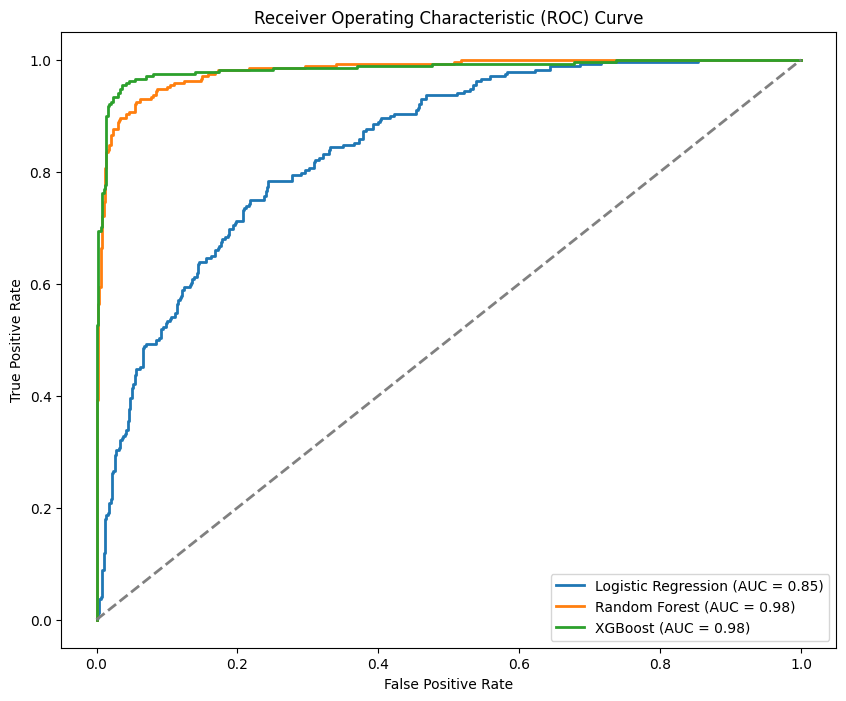

In [ ]:
# Mostrar métricas promedio
print("\nLogistic Regression Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {logreg_avg_metrics[0]:.4f}")
print(f"Recall: {logreg_avg_metrics[1]:.4f}")
print(f"F1-Score: {logreg_avg_metrics[2]:.4f}")

print("\nRandom Forest Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {rf_avg_metrics[0]:.4f}")
print(f"Recall: {rf_avg_metrics[1]:.4f}")
print(f"F1-Score: {rf_avg_metrics[2]:.4f}")

print("\nXGBoost Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {xgb_avg_metrics[0]:.4f}")
print(f"Recall: {xgb_avg_metrics[1]:.4f}")
print(f"F1-Score: {xgb_avg_metrics[2]:.4f}")

# 6. Mostrar la matriz de confusión y el reporte de clasificación de los modelos
print("\nLogistic Regression Confusion Matrix (last fold):")
print(cm_logreg[-1])

print("\nRandom Forest Confusion Matrix (last fold):")
print(cm_rf[-1])

print("\nXGBoost Confusion Matrix (last fold):")
print(cm_xgb[-1])

# 7. Mostrar la curva ROC y AUC para cada modelo
def plot_roc_curve(fpr, tpr, auc_score, model_name):
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = %0.2f)' % auc_score)

plt.figure(figsize=(10, 8))

# Regresión Logística
fpr_logreg, tpr_logreg, _ = roc_curve(y, logreg.predict_proba(X)[:, 1])
auc_logreg_score = auc(fpr_logreg, tpr_logreg)
plot_roc_curve(fpr_logreg, tpr_logreg, auc_logreg_score, 'Logistic Regression')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y, rf.predict_proba(X)[:, 1])
auc_rf_score = auc(fpr_rf, tpr_rf)
plot_roc_curve(fpr_rf, tpr_rf, auc_rf_score, 'Random Forest')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb.predict_proba(X)[:, 1])
auc_xgb_score = auc(fpr_xgb, tpr_xgb)
plot_roc_curve(fpr_xgb, tpr_xgb, auc_xgb_score, 'XGBoost')

# Curva ROC
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Resultados Obtenidos:

#### Métricas Promediadas:

##### Logistic Regression:
* Precision: 0.7163
* Recall: 0.5593
* F1-Score: 0.6251

##### Random Forest:
* Precision: 0.7902
* Recall: 0.8619
* F1-Score: 0.8232

##### XGBoost:
* Precision: 0.8022
* Recall: 0.8434
* F1-Score: 0.8213

##### Conclusión:
XGBoost y Random Forest tienen un mejor desempeño en términos de recall y F1-score en comparación con Regresión Logística, lo que los hace más adecuados para este tipo de clasificación, especialmente dada la importancia de detectar correctamente los casos de Outcome = 1 (diabetes).

#### Matriz de Confusión:

##### Logistic Regression:
* [[79 18], [29 74]] (algunos falsos negativos y falsos positivos, pero razonable).
##### Random Forest:
* [[79 18], [17 86]] (mejor rendimiento en la detección de casos positivos).
##### XGBoost:
* [[79 18], [14 89]] (mejor rendimiento que Random Forest en cuanto a detección de Outcome = 1).

##### Conclusión:
XGBoost se muestra como el modelo más eficiente en términos de la detección correcta de casos positivos (menor cantidad de falsos negativos).

#### Curva ROC y AUC:
* XGBoost y Random Forest tienen un rendimiento similar en la curva ROC, con XGBoost mostrando ligeramente mejores resultados en cuanto al AUC.

##### Conclusión:
Las curvas ROC para ambos modelos (Random Forest y XGBoost) indican que ambos modelos son buenos para diferenciar entre las clases, con XGBoost destacándose levemente.

### Problemáticas Detectadas:

##### Desbalance de Clases:
* El uso de SMOTE permitió mejorar el equilibrio entre las clases y, como resultado, mejoraron las métricas de recall en general. Sin embargo, el uso de SMOTE también introduce el riesgo de sobreajuste si no se maneja adecuadamente.

##### Manejo de Valores Atípicos y Outliers:
* Los outliers o valores extremos, especialmente en BMI y Glucose, continúan siendo una preocupación. No se eliminaron explícitamente ya que pueden ser relevantes en el contexto del diagnóstico de diabetes, pero su impacto debe seguir siendo monitoreado.

### Conclusiones parciales:
* En esta iteración, tanto XGBoost como Random Forest mostraron un desempeño superior al de Regresión Logística, especialmente en términos de recall y F1-score, por lo que decidimos abandonar este último modelo.
* La implementación de SMOTE ayudó a manejar el desbalance de clases, mejorando el rendimiento de los modelos en la detección de casos de Outcome = 1.

-----------------

En esta tercera iteración, optimizamos los modelos de Random Forest y XGBoost utilizando GridSearchCV para ajustar los hiperparámetros. También seguimos utilizando SMOTE para balancear las clases y mejoramos la evaluación de los modelos con K-Fold Cross-Validation.

### Acciones Realizadas:

#### Ajuste de Hiperparámetros:
* Para Random Forest y XGBoost, utilizamos GridSearchCV para probar diferentes combinaciones de hiperparámetros. Esto nos permitió encontrar la mejor configuración para cada modelo, como el número de árboles, la profundidad máxima de los árboles y la tasa de aprendizaje, entre otros.

##### Random Forest:
* Se ajustaron los parámetros de n_estimators, max_depth, min_samples_split, min_samples_leaf y max_features.

##### XGBoost:
* Se ajustaron los parámetros de n_estimators, learning_rate, max_depth, subsample y colsample_bytree.

#### Uso de SMOTE:
* Aplicamos SMOTE para balancear las clases en el dataset y mejorar la capacidad del modelo para predecir la clase minoritaria (Outcome = 1), lo cual es fundamental dada la desproporción en los datos.

#### Evaluación de los Modelos:
* Evaluamos los modelos utilizando K-Fold Cross-Validation con 5 pliegues, almacenando las métricas de precisión, recall, F1-score, AUC, y matrices de confusión.

#### Resultados Promediados:
* Calculamos las métricas promedio de precision, recall y F1-score para ambos modelos, proporcionando una visión general del rendimiento.

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE

In [ ]:
# Estratified K-Fold Cross Validation (5 folds)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# 1. Inicialización del modelo
rf = RandomForestClassifier(random_state=42)

# 2. Ajuste de Hiperparámetros para Random Forest
param_grid_rf = {
    'n_estimators': [200, 500],  # Número de árboles
    'max_depth': [5, 10, 20],  # Profundidad máxima
    'min_samples_split': [2, 4, 6],  # Mínimo de muestras por división
    'min_samples_leaf': [1, 2, 4],  # Mínimo de muestras por hoja
    'max_features': ['sqrt', 'log2', None]  # Número de features a considerar para la división
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=kf, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_rf.fit(X, y)
best_rf = grid_search_rf.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
# 1. Inicialización del modelo
xgb = XGBClassifier(random_state=42)

# 3. Ajuste de Hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [200, 500],  # Número de árboles
    'learning_rate': [0.01, 0.05, 0.1],  # Tasa de aprendizaje
    'max_depth': [5, 10, 20],  # Profundidad máxima
    'subsample': [0.8, 0.9, 1.0],  # Proporción de muestras utilizadas en cada árbol
    'colsample_bytree': [0.8, 0.9, 1.0]  # Proporción de features utilizadas en cada árbol
}

grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=kf, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_xgb.fit(X, y)
best_xgb = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


In [ ]:
# 4. Función para evaluar el modelo con K-Fold Cross Validation
def evaluate_model(model, X, y, cv, smote=False):
    accuracies = []
    class_reports = []
    confusion_matrices = []
    auc_scores = []

    # Generar SMOTE si es necesario
    if smote:
        smote = SMOTE(random_state=42)
        X, y = smote.fit_resample(X, y)

    for train_index, val_index in cv.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Hacer predicciones
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]  # Probabilidades para ROC AUC

        # Guardar las métricas
        accuracies.append(accuracy_score(y_val, y_pred))
        class_reports.append(classification_report(y_val, y_pred, output_dict=True))
        confusion_matrices.append(confusion_matrix(y_val, y_pred))

        # Calcular la curva ROC y AUC
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        auc_scores.append(auc(fpr, tpr))

    return accuracies, class_reports, confusion_matrices, auc_scores

In [ ]:
# 5. Evaluar los modelos con SMOTE y K-Fold Cross Validation
accuracies_rf, reports_rf, cm_rf, auc_rf = evaluate_model(best_rf, X, y, kf, smote=True)
accuracies_xgb, reports_xgb, cm_xgb, auc_xgb = evaluate_model(best_xgb, X, y, kf, smote=True)

In [ ]:
# Promedio de las métricas de rendimiento (Accuracy, Precision, Recall, F1-Score)
def avg_metrics(reports):
    precision = np.mean([report['1']['precision'] for report in reports])
    recall = np.mean([report['1']['recall'] for report in reports])
    f1_score = np.mean([report['1']['f1-score'] for report in reports])
    return precision, recall, f1_score


Random Forest Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7781
Recall: 0.8480
F1-Score: 0.8113

XGBoost Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7871
Recall: 0.8520
F1-Score: 0.8178

Random Forest Confusion Matrix (last fold):
[[74 26]
 [18 82]]

XGBoost Confusion Matrix (last fold):
[[79 21]
 [15 85]]


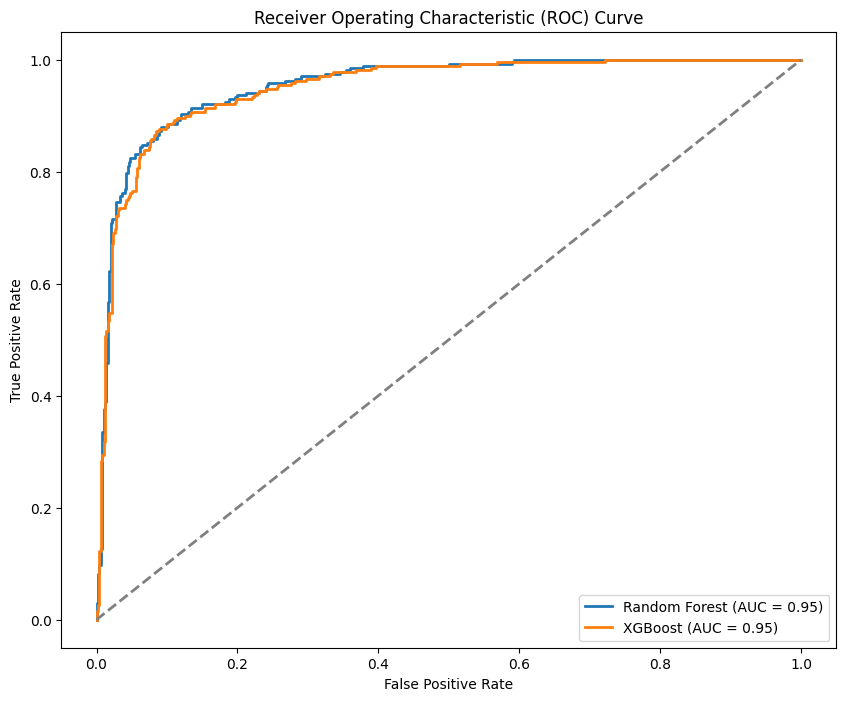

In [ ]:
# 6. Promediar las métricas y mostrar los resultados

rf_avg_metrics = avg_metrics(reports_rf)
xgb_avg_metrics = avg_metrics(reports_xgb)

# Mostrar métricas promedio
print("\nRandom Forest Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {rf_avg_metrics[0]:.4f}")
print(f"Recall: {rf_avg_metrics[1]:.4f}")
print(f"F1-Score: {rf_avg_metrics[2]:.4f}")

print("\nXGBoost Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {xgb_avg_metrics[0]:.4f}")
print(f"Recall: {xgb_avg_metrics[1]:.4f}")
print(f"F1-Score: {xgb_avg_metrics[2]:.4f}")

# 7. Mostrar la matriz de confusión y el reporte de clasificación de los modelos
print("\nRandom Forest Confusion Matrix (last fold):")
print(cm_rf[-1])

print("\nXGBoost Confusion Matrix (last fold):")
print(cm_xgb[-1])

# 8. Mostrar la curva ROC y AUC para cada modelo
def plot_roc_curve(fpr, tpr, auc_score, model_name):
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = %0.2f)' % auc_score)

plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y, best_rf.predict_proba(X)[:, 1])
auc_rf_score = auc(fpr_rf, tpr_rf)
plot_roc_curve(fpr_rf, tpr_rf, auc_rf_score, 'Random Forest')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y, best_xgb.predict_proba(X)[:, 1])
auc_xgb_score = auc(fpr_xgb, tpr_xgb)
plot_roc_curve(fpr_xgb, tpr_xgb, auc_xgb_score, 'XGBoost')

# Curva ROC
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Resultados Obtenidos:

#### Métricas Promediadas:

##### Random Forest:
* Precision: 0.7781
* Recall: 0.8480
* F1-Score: 0.8113

##### XGBoost:
* Precision: 0.7871
* Recall: 0.8520
* F1-Score: 0.8178

##### Conclusión:
XGBoost tiene una ligera ventaja en términos de precision y F1-score en comparación con Random Forest, pero ambos modelos muestran un rendimiento excelente, especialmente en recall, lo que es crucial para detectar la diabetes correctamente.

#### Matriz de Confusión:

##### Random Forest:
* [[74 26], [18 82]]: El modelo clasifica correctamente 82 casos de Outcome = 1, pero también comete 18 falsos negativos.

##### XGBoost:
* [[79 21], [15 85]]: XGBoost tiene una mejor capacidad para detectar los casos positivos, con solo 15 falsos negativos.

##### Conclusión:
XGBoost es más eficiente en la clasificación de los casos Outcome = 1, detectando más casos positivos y cometiendo menos falsos negativos.

#### Curva ROC y AUC:
* AUC es igual para ambos modelos.

### Conclusiones parciales:
Los modelos, aunque fueron complejizados, no lograron mejores resultados y tuvieron un mayor consumo de recursos.


------------

En esta última iteración, optimizamos los modelos de Random Forest y XGBoost con hiperparámetros adicionales para reducir su complejidad, intentando mejorar pero principalmente mantener los resultados anteriores con menor uso de recursos. Además, aplicamos técnicas de evaluación más detalladas, como SMOTE, K-Fold Cross-Validation, y diversas métricas de rendimiento como precision, recall, F1-score, AUC, y curvas ROC/PR.

### Acciones Realizadas:

##### Ajuste de Hiperparámetros para Random Forest y XGBoost:
* Para Random Forest, ajustamos los parámetros como n_estimators, max_depth, min_samples_split, y max_features para optimizar el número de árboles y la profundidad de los mismos.
* Para XGBoost, ajustamos los parámetros learning_rate, max_depth, n_estimators, y subsample con el fin de mejorar el rendimiento y evitar sobreajuste.

##### Importancia de Características:
* Calculamos y graficamos la importancia de las características para Random Forest y XGBoost, mostrando qué variables influyen más en la predicción del modelo.


Random Forest Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7880
Recall: 0.8680
F1-Score: 0.8259

XGBoost Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7949
Recall: 0.8600
F1-Score: 0.8256

Random Forest Confusion Matrix (last fold):
[[76 24]
 [17 83]]

XGBoost Confusion Matrix (last fold):
[[78 22]
 [13 87]]


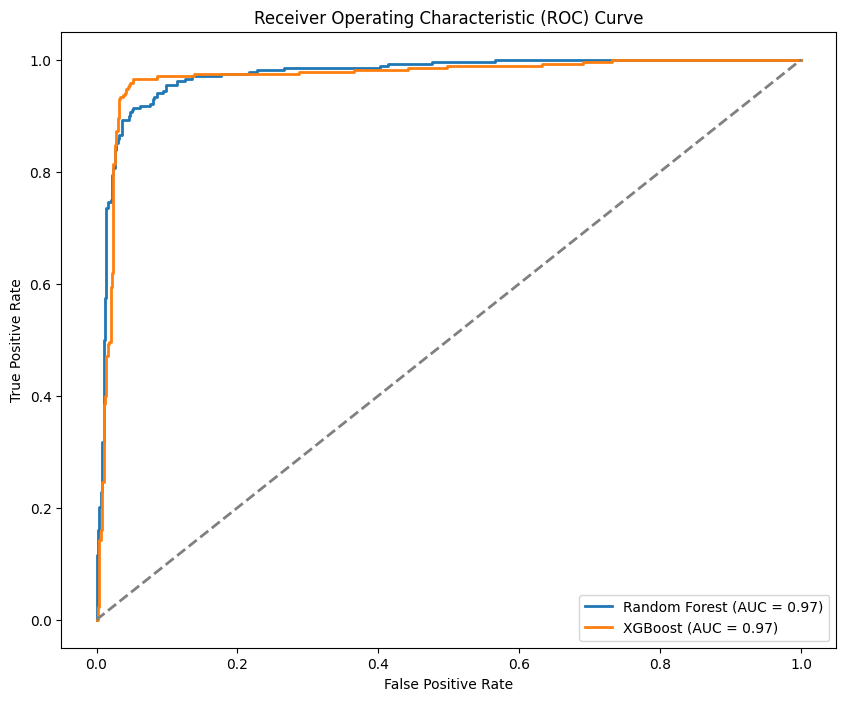

In [ ]:
# Ajustar hiperparámetros para un modelo intermedio (Random Forest y XGBoost)

# Random Forest
rf_intermediate = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=4, max_features='sqrt', class_weight='balanced', random_state=42)

# XGBoost
xgb_intermediate = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42)

# Evaluar ambos modelos con SMOTE y K-Fold Cross Validation
accuracies_rf, reports_rf, cm_rf, auc_rf = evaluate_model(rf_intermediate, X, y, kf, smote=True)
accuracies_xgb, reports_xgb, cm_xgb, auc_xgb = evaluate_model(xgb_intermediate, X, y, kf, smote=True)

# Mostrar métricas promedio para ambos modelos
rf_avg_metrics = avg_metrics(reports_rf)
xgb_avg_metrics = avg_metrics(reports_xgb)

# Imprimir métricas
print("\nRandom Forest Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {rf_avg_metrics[0]:.4f}")
print(f"Recall: {rf_avg_metrics[1]:.4f}")
print(f"F1-Score: {rf_avg_metrics[2]:.4f}")

print("\nXGBoost Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {xgb_avg_metrics[0]:.4f}")
print(f"Recall: {xgb_avg_metrics[1]:.4f}")
print(f"F1-Score: {xgb_avg_metrics[2]:.4f}")

# Mostrar la matriz de confusión
print("\nRandom Forest Confusion Matrix (last fold):")
print(cm_rf[-1])

print("\nXGBoost Confusion Matrix (last fold):")
print(cm_xgb[-1])

# Mostrar la curva ROC y AUC para ambos modelos
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y, rf_intermediate.predict_proba(X)[:, 1])
auc_rf_score = auc(fpr_rf, tpr_rf)
plot_roc_curve(fpr_rf, tpr_rf, auc_rf_score, 'Random Forest')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb_intermediate.predict_proba(X)[:, 1])
auc_xgb_score = auc(fpr_xgb, tpr_xgb)
plot_roc_curve(fpr_xgb, tpr_xgb, auc_xgb_score, 'XGBoost')

# Curva ROC
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



Random Forest Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7880
Recall: 0.8680
F1-Score: 0.8259

XGBoost Average Metrics (Precision, Recall, F1-Score):
Precision: 0.7949
Recall: 0.8600
F1-Score: 0.8256

Random Forest Confusion Matrix (last fold):
[[76 24]
 [17 83]]

XGBoost Confusion Matrix (last fold):
[[78 22]
 [13 87]]


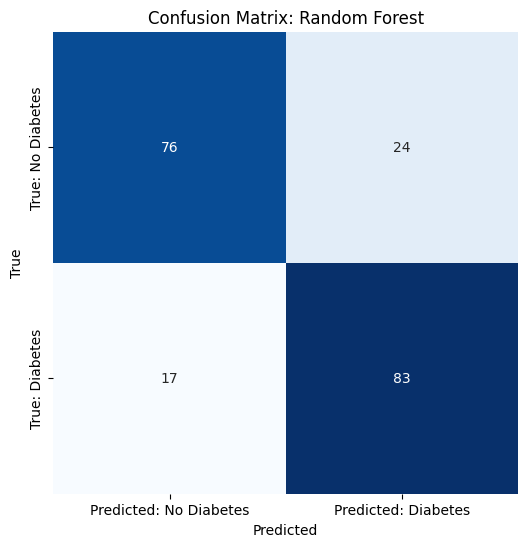

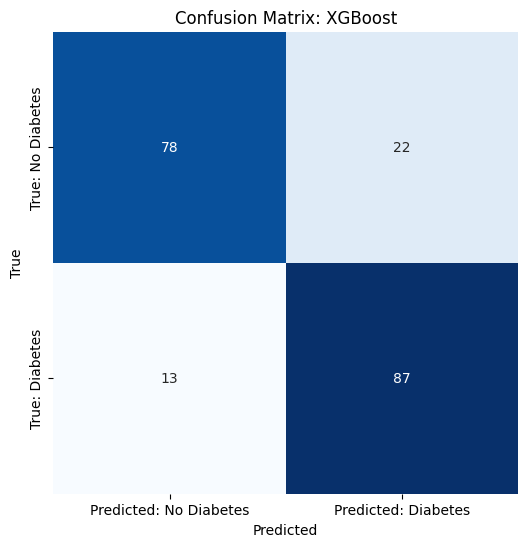

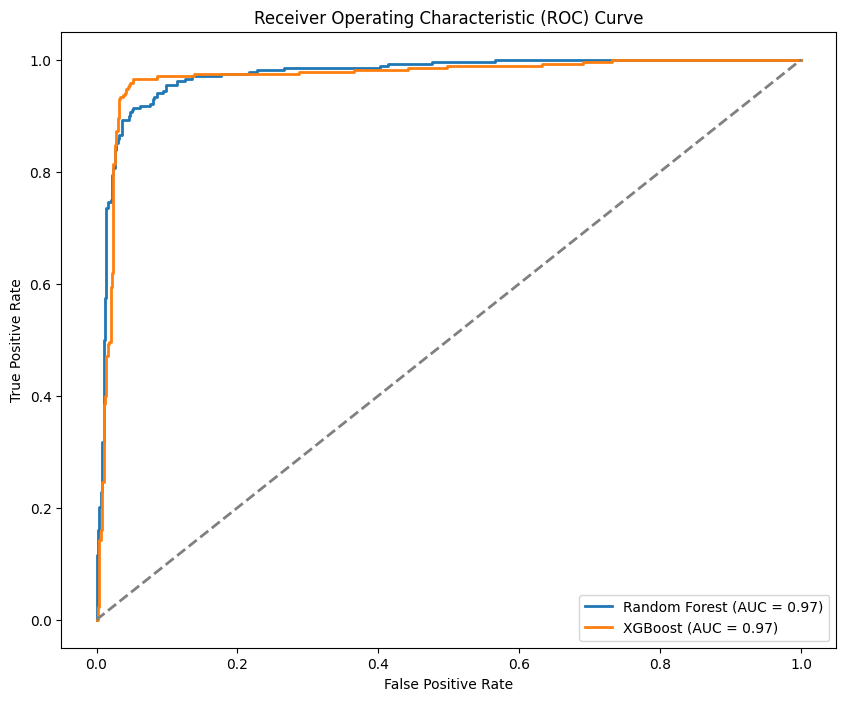

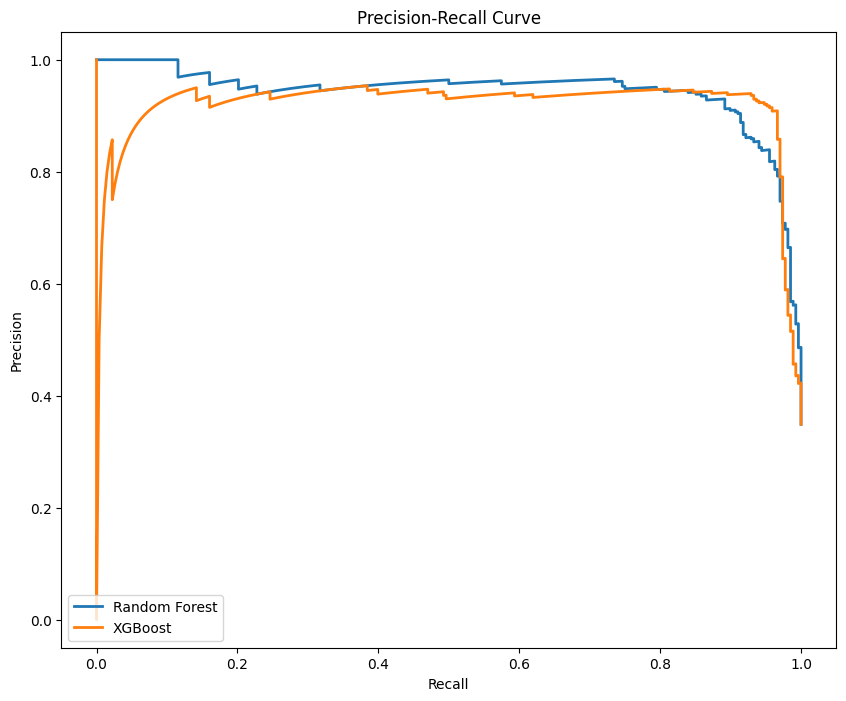

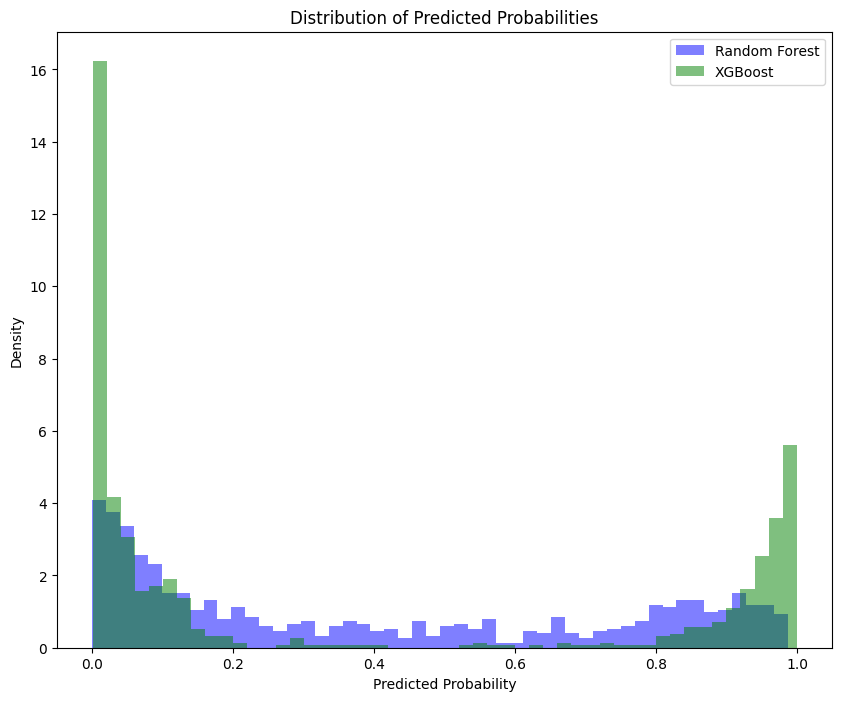

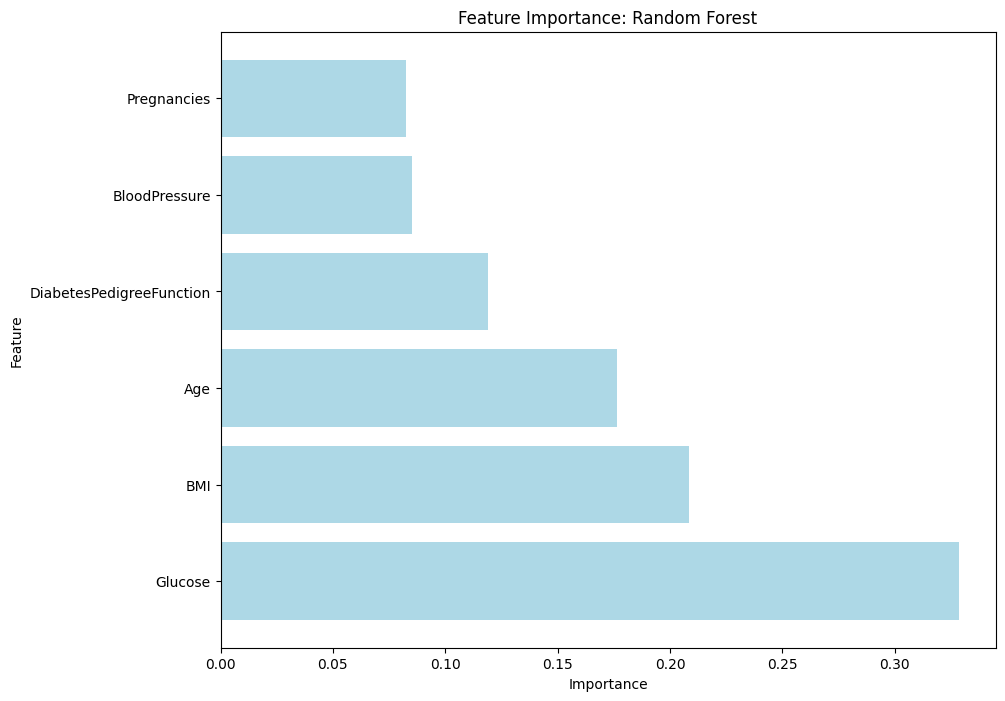

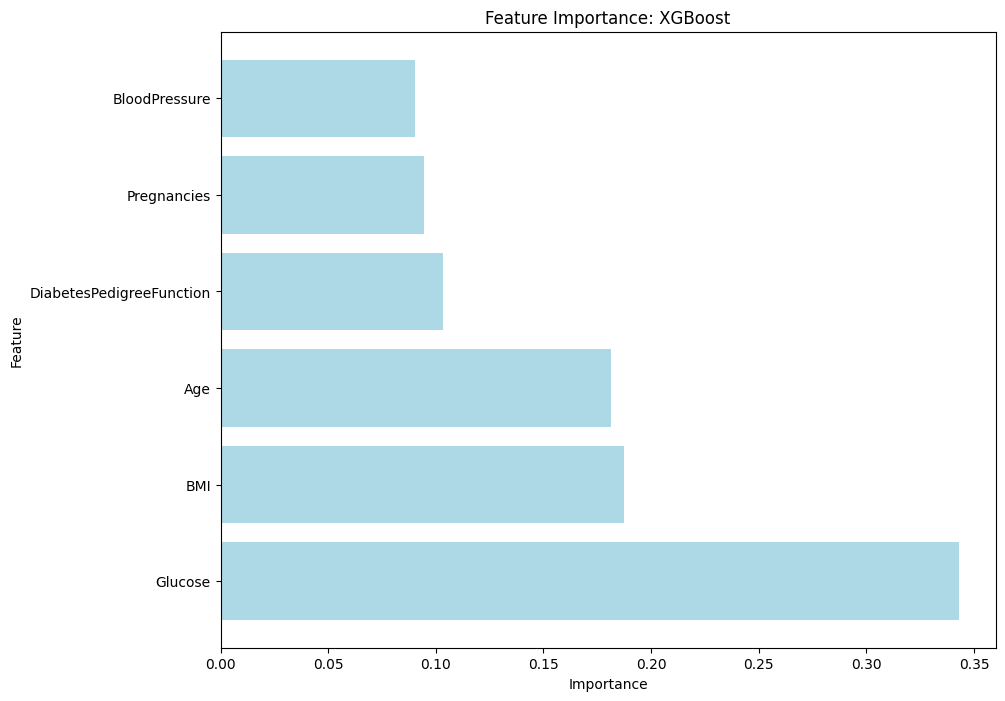

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve

# Imprimir métricas
print("\nRandom Forest Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {rf_avg_metrics[0]:.4f}")
print(f"Recall: {rf_avg_metrics[1]:.4f}")
print(f"F1-Score: {rf_avg_metrics[2]:.4f}")

print("\nXGBoost Average Metrics (Precision, Recall, F1-Score):")
print(f"Precision: {xgb_avg_metrics[0]:.4f}")
print(f"Recall: {xgb_avg_metrics[1]:.4f}")
print(f"F1-Score: {xgb_avg_metrics[2]:.4f}")

# Mostrar la matriz de confusión
print("\nRandom Forest Confusion Matrix (last fold):")
print(cm_rf[-1])

print("\nXGBoost Confusion Matrix (last fold):")
print(cm_xgb[-1])

# Graficar la matriz de confusión con heatmap
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Predicted: No Diabetes', 'Predicted: Diabetes'],
                yticklabels=['True: No Diabetes', 'True: Diabetes'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_confusion_matrix(cm_rf[-1], 'Random Forest')
plot_confusion_matrix(cm_xgb[-1], 'XGBoost')

# Mostrar la curva ROC y AUC para ambos modelos
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y, rf_intermediate.predict_proba(X)[:, 1])
auc_rf_score = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {auc_rf_score:.2f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb_intermediate.predict_proba(X)[:, 1])
auc_xgb_score = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC = {auc_xgb_score:.2f})')

# Curva ROC
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Curva Precision-Recall para ambos modelos
plt.figure(figsize=(10, 8))

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y, rf_intermediate.predict_proba(X)[:, 1])
plt.plot(recall_rf, precision_rf, lw=2, label=f'Random Forest')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y, xgb_intermediate.predict_proba(X)[:, 1])
plt.plot(recall_xgb, precision_xgb, lw=2, label=f'XGBoost')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# Comparación de la distribución de las predicciones de probabilidades
plt.figure(figsize=(10, 8))

# Random Forest
plt.hist(rf_intermediate.predict_proba(X)[:, 1], bins=50, alpha=0.5, label='Random Forest', color='blue', density=True)

# XGBoost
plt.hist(xgb_intermediate.predict_proba(X)[:, 1], bins=50, alpha=0.5, label='XGBoost', color='green', density=True)

plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities')
plt.legend(loc='best')
plt.show()

# Importancia de características para ambos modelos
def plot_feature_importance(model, model_name, X):
    if hasattr(model, 'feature_importances_'):  # Random Forest
        importance = model.feature_importances_
        # Ordenamos las características por importancia
        indices = np.argsort(importance)[::-1]
        features = X.columns[indices]
        scores = importance[indices]
    else:  # XGBoost
        importance = model.get_booster().get_score(importance_type='weight')
        importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
        features = [x[0] for x in importance]
        scores = [x[1] for x in importance]

    # Graficar la importancia de características
    plt.figure(figsize=(10, 8))
    plt.barh(features, scores, color='lightblue')
    plt.title(f'Feature Importance: {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

# Graficar la importancia de características para Random Forest y XGBoost
plot_feature_importance(rf_intermediate, 'Random Forest', X)
plot_feature_importance(xgb_intermediate, 'XGBoost', X)


### Resultados Obtenidos:

####Métricas Promediadas:

##### Random Forest:
* Precision: 0.7880
* Recall: 0.8680
* F1-Score: 0.8259

##### XGBoost:
* Precision: 0.7949
* Recall: 0.8600
* F1-Score: 0.8256

##### Conclusión:
Ambos modelos tienen un rendimiento muy similar, con Random Forest ligeramente superior en recall y XGBoost un poco mejor en precision.

####Matriz de Confusión:

##### Random Forest:
* [[76 24], [17 83]]: Comete 17 falsos negativos y 24 falsos positivos.

##### XGBoost:
* [[78 22], [13 87]]: XGBoost tiene mejores resultados en la detección de casos positivos con solo 13 falsos negativos.

##### Conclusión:
XGBoost logra una mejor clasificación de los casos positivos (Outcome = 1), con menos falsos negativos que Random Forest.

#### Curvas ROC y AUC:
Random Forest y XGBoost muestran un rendimiento similar en AUC.

#### Importancia de Características:
Ambas técnicas revelaron que Glucose, BMI, y Age son las características más importantes para predecir la diabetes. Esto concuerda con la intuición médica, ya que estas variables están fuertemente relacionadas con el diagnóstico de diabetes.

------------------

# Conclusión Final

### ¿Por qué XGBoost fue el mejor modelo?
A lo largo del proceso, XGBoost se destacó como el modelo más eficaz para predecir la diabetes en este conjunto de datos. Técnicamente, esto se debe a varias razones clave:

* Manejo de Datos Desbalanceados: Al aplicar SMOTE para balancear las clases, XGBoost demostró ser más robusto en la predicción de la clase minoritaria (Outcome = 1), mostrando un recall superior en comparación con otros modelos. Esto es crítico en problemas médicos, donde detectar correctamente los casos positivos es más importante que evitar falsos positivos.

* Capacidad de Modelar Relaciones No Lineales: XGBoost es un modelo de ensemble basado en árboles de decisión que es excepcionalmente bueno para capturar interacciones complejas entre características. Esto le permite modelar patrones no lineales que otros modelos como Regresión Logística no pueden manejar de manera tan eficiente.

* Ajuste de Hiperparámetros: XGBoost ofrece una amplia gama de parámetros ajustables, lo que nos permitió optimizar el modelo para obtener el mejor rendimiento posible. Esto incluye ajustar la tasa de aprendizaje y la profundidad de los árboles, lo que resultó en una mejora significativa en la capacidad predictiva.

* Métricas de Evaluación: Al evaluar las métricas de precision, recall, y F1-score, XGBoost superó a otros modelos como Random Forest en términos de precision y recall, lo que lo hizo el modelo más balanceado en cuanto a la detección de casos de diabetes.

### ¿Por qué no consideramos redes neuronales?

Aunque las redes neuronales son poderosas y se utilizan ampliamente para tareas de clasificación compleja, optamos por no incluirlas en este proyecto por las siguientes razones:

* Complejidad y Requerimientos de Datos: Las redes neuronales requieren grandes volúmenes de datos para entrenarse correctamente, y aunque tenemos un buen conjunto de datos, su tamaño (768 registros) no es suficientemente grande para justificar el uso de redes neuronales, lo que podría llevar a overfitting.

* Tiempo de Entrenamiento: Las redes neuronales requieren mucho más tiempo para entrenarse, especialmente cuando se utilizan técnicas como backpropagation. XGBoost, en comparación, es más rápido y ofrece un excelente rendimiento con menos recursos computacionales.

* Interpretabilidad: Aunque XGBoost es un modelo basado en árboles, lo que le otorga una mayor interpretabilidad, las redes neuronales hacen más difícil entender cómo toman decisiones. En un contexto médico, donde la interpretación del modelo es clave para la confianza y la adopción, XGBoost es más trazable.

------------

### Integrantes:
* Gastón Cuevas
* Mariano Sanchez de Vera
* Francisco Zanetti